### Imports and Such

In [1]:
# Adjust import path
import sys
sys.path.append("../PDEs")
sys.path.append("../")

In [2]:
import os
import h5py
import numpy as np

import opinf

import config_fhnlifted as config
import utils
import step1_generate_data as step1
import step2_fitgps as step2
import step3_estimate as step3
import step4_plot as step4

import matplotlib.pyplot as plt

from jax_gp import *

Logging to log.log


In [3]:
training_span = (0, 6) # (0, 6)
num_samples= 400 # 400
noiselevel= .0 # 0
num_regression_points= 400 # 400
numPODmodes= 3 # 3
gp_regularizer= 1e-4 # 1e-4
ndraws=100 # 100
exportto=None
openonsave=False
ddtdata=False

config.time_domain = np.linspace(0, 8, 801)  # Temporal domain t.

In [4]:
if isinstance(numPODmodes, (list, tuple)) and len(numPODmodes) == 1:
    numPODmodes = numPODmodes[0]

# Report on experimental scenario.
utils.summarize_experiment(
    training_span=training_span,
    num_samples=num_samples,
    noiselevel=noiselevel,
    num_regression_points=num_regression_points,
    numPODmodes=numPODmodes,
    gp_regularizer=gp_regularizer,
    ndraws=ndraws,
)

# Step 1: Generate data ---------------------------------------------------
(
    model,
    time_domain,
    true_states,
    time_domain_sampled,
    snapshots_sampled,
) = step1.trajectory(training_span, num_samples, config, noiselevel)

time_domain_training = np.linspace(
    training_span[0],
    training_span[-1],
    num_regression_points,
)


EXPERIMENTAL SCENARIO
Data: 400 uniformly sampled snapshots over 0.00 ≤ t < 6.00 with 0.00% noise
Dimension: retaining 3 POD modes
Training: using 400 regression points
GP regularization: eta = 1.00e-04
Posterior: 100 draws

generating training data...done in 0.36 s.


In [5]:
### Extra params

figsize = (12,6)

### Fit Guassian Processes

In [6]:
# Dimensionality reduction (POD).
with opinf.utils.TimedBlock(
    f"reducing noisy training states to {numPODmodes} dimensions"
):
    basis = config.Basis(num_vectors=numPODmodes)
    print(basis)
    print(f"Snapshot sampled shape: {snapshots_sampled.shape}")
    basis.fit(snapshots_sampled)
    # print(f"{}")
    snapshots_compressed = basis.compress(snapshots_sampled)
    full_states_compressed = basis.compress(true_states)
    print(full_states_compressed.shape)

reducing noisy training states to 3 dimensions...Basis
  full_state_dimension:    None
  reduced_state_dimension: None
  SVD solver: scipy.linalg.svd()
Snapshot sampled shape: (1024, 400)
(512, 400) (512, 400)
(3, 801)
done in 0.04 s.


INFO:2025-06-13 12:59:26,750:jax._src.xla_bridge:867: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/Users/anthonypoole/miniconda3/envs/jax/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)


(400, 1) (1, 400)
Iter   0, neg-log-lik = 357653.6250
Iter  10, neg-log-lik = 305621.4062
Iter  20, neg-log-lik = 255689.8594
Iter  30, neg-log-lik = 216319.6875
Iter  40, neg-log-lik = 188451.4375
Iter  50, neg-log-lik = 165392.9062
Iter  60, neg-log-lik = 143597.9531
Iter  70, neg-log-lik = 116846.8984
Iter  80, neg-log-lik = 80146.1797
Iter  90, neg-log-lik = 57461.0977
Iter 100, neg-log-lik = 48098.2070
Iter 110, neg-log-lik = 42333.1445
Iter 120, neg-log-lik = 38010.5781
Iter 130, neg-log-lik = 34563.2461
Iter 140, neg-log-lik = 31681.7988
Iter 150, neg-log-lik = 29105.1387
Iter 160, neg-log-lik = 26656.4707
Iter 170, neg-log-lik = 24307.2500
Iter 180, neg-log-lik = 22150.8203
Iter 190, neg-log-lik = 20266.7656
Iter 200, neg-log-lik = 18625.7168
Iter 210, neg-log-lik = 17147.4805
Iter 220, neg-log-lik = 15773.8555
Iter 230, neg-log-lik = 14500.8340
Iter 240, neg-log-lik = 13360.4326
Iter 250, neg-log-lik = 12377.5850
Iter 260, neg-log-lik = 11546.3877
Iter 270, neg-log-lik = 10839

/var/folders/z5/hb7nxgp524b67trvdyv41twh0000gn/T/ipykernel_56679/1467980428.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


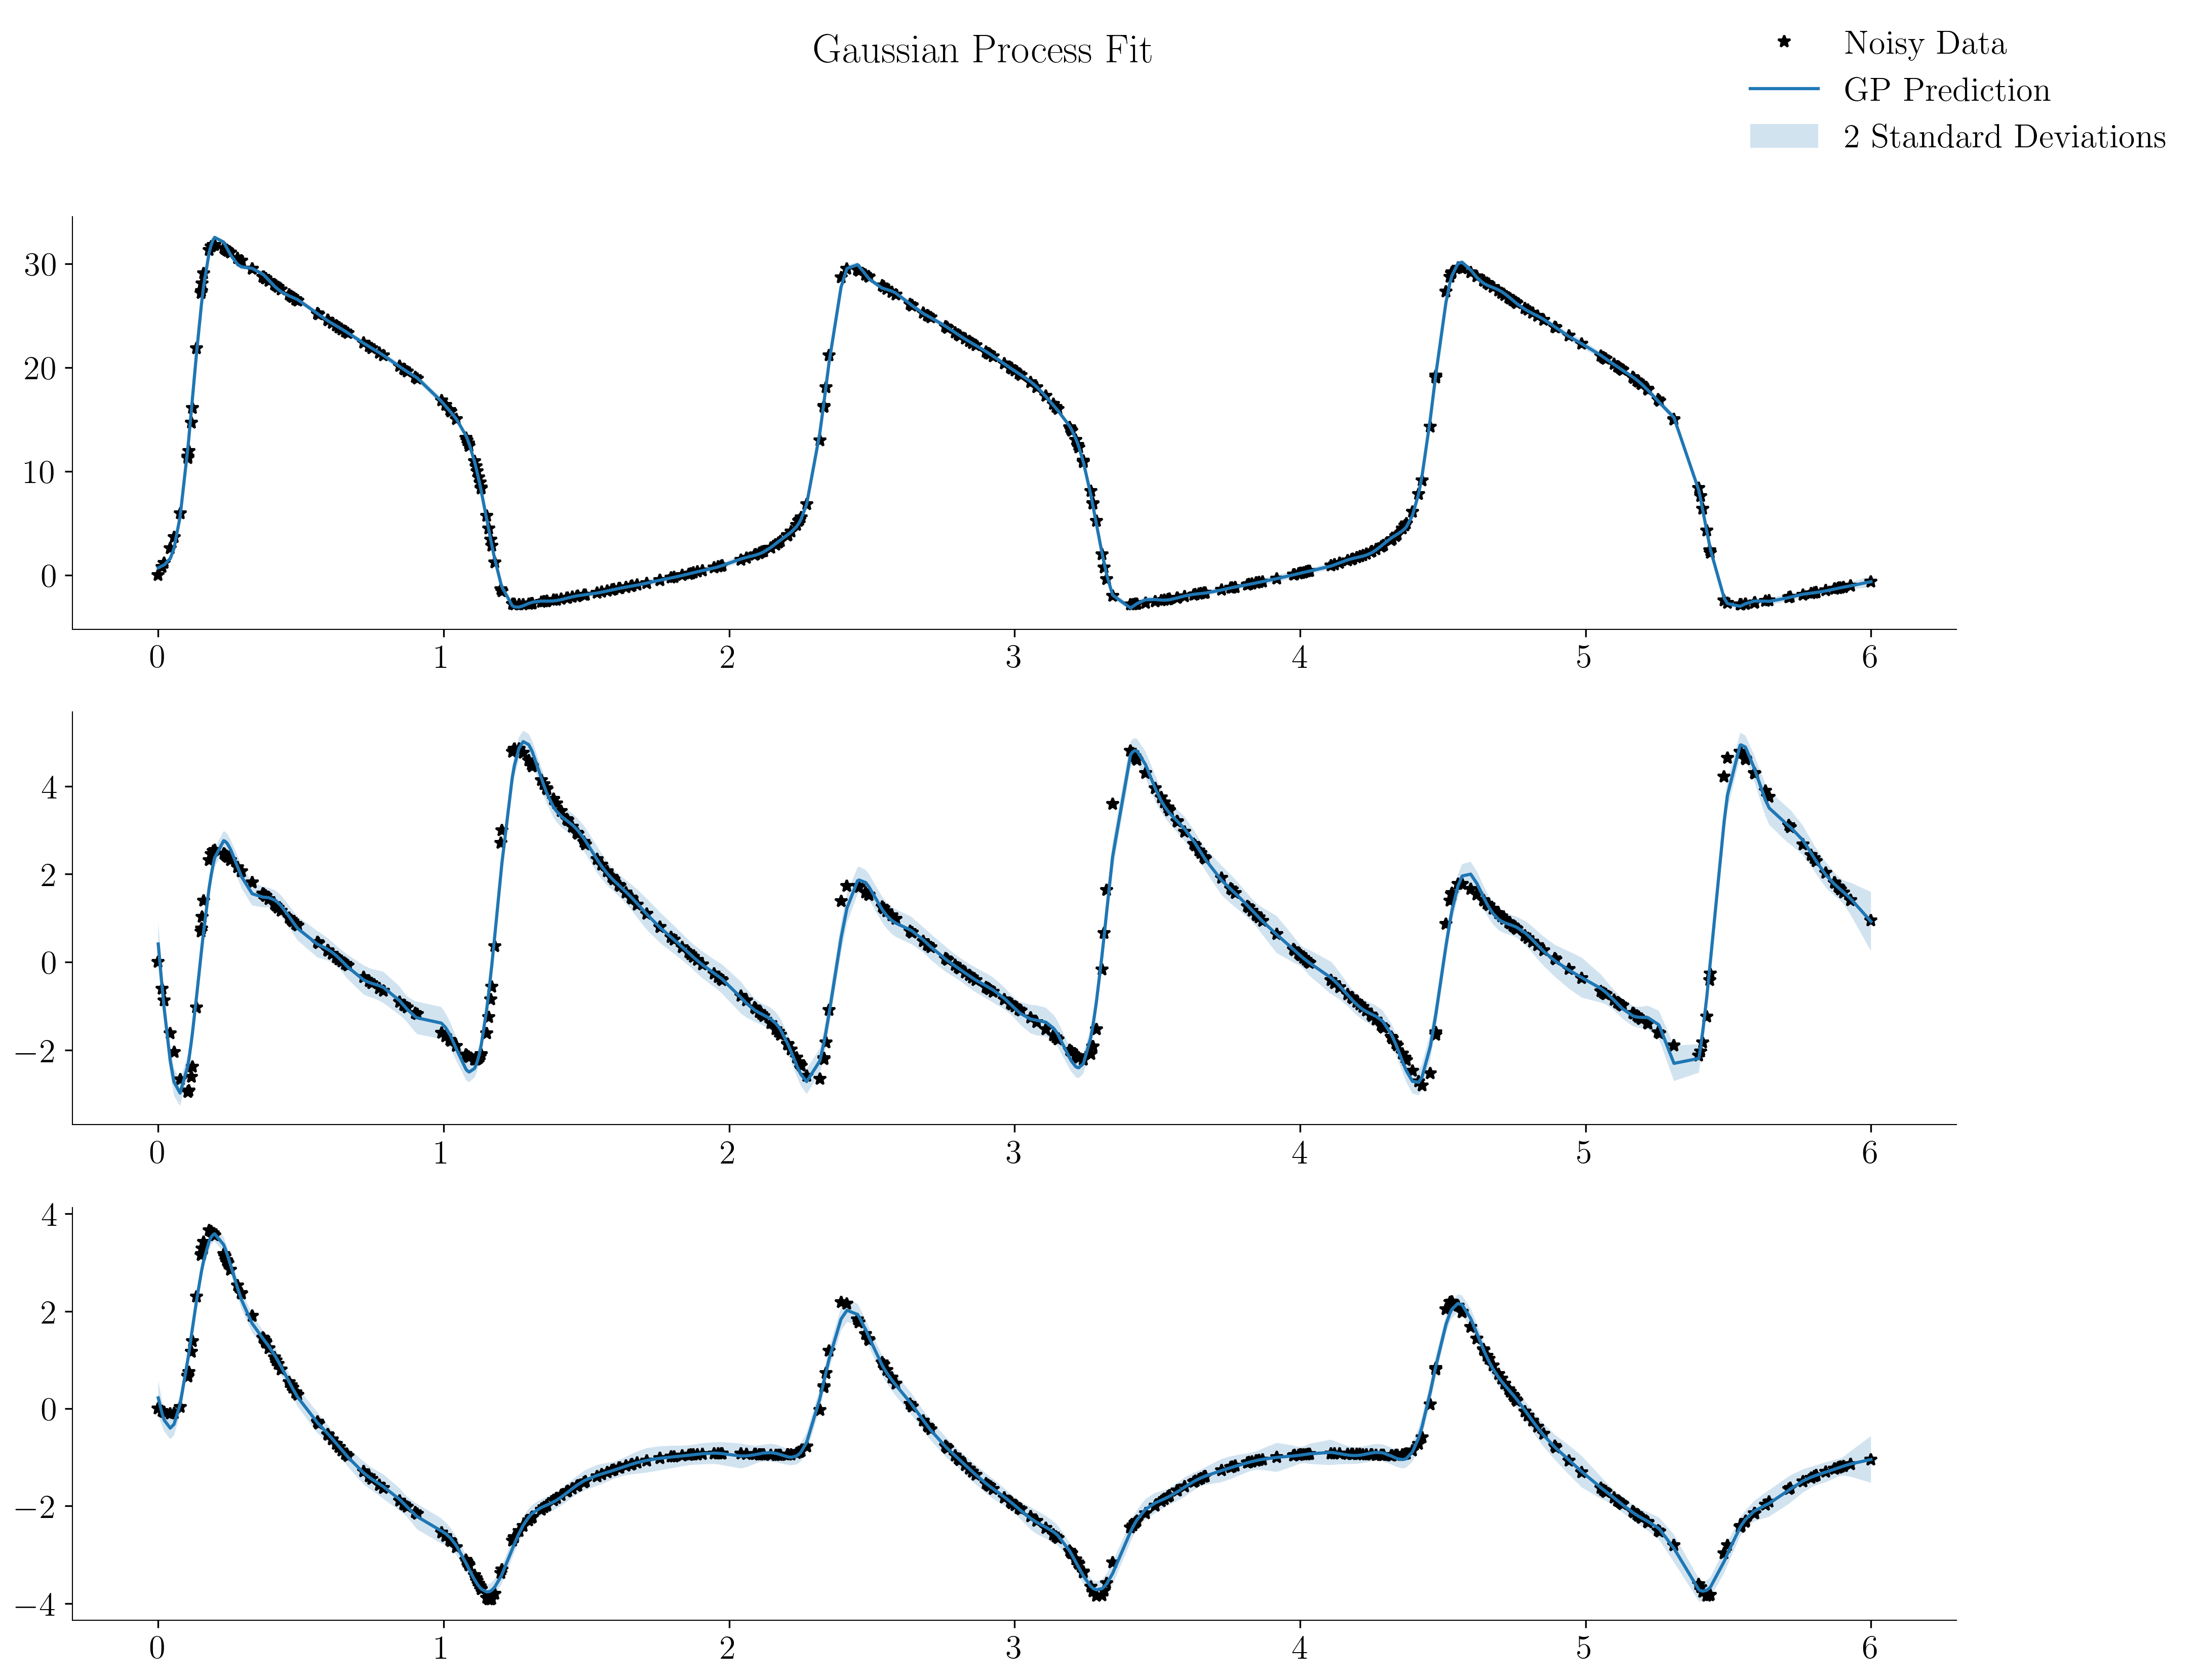

In [7]:
gps = []
gp_state_preds = []
fig, ax = plt.subplots(numPODmodes, 1, figsize=(16,12))
for mode in range(numPODmodes):
    gp = GaussianProcess(standardize=False)
    # gp = GaussianProcess(init_params={'variance': 2.1959e+00, 'lengthscale': 4.6282e-02, 'noise': 8.6918e-04})
    print(time_domain_sampled[:,None].shape, snapshots_compressed[mode, :].reshape(1, time_domain_sampled.size).shape)
    gp.fit(X = time_domain_sampled[:,None], y = snapshots_compressed[mode, :].reshape(1, time_domain_sampled.size), n_iter=1000)
    gps.append(gp)

    pred_mu, pred_cov = gp.predict(X_train=time_domain_sampled[:,None], 
                      y_train=snapshots_compressed[mode, :].reshape(time_domain_sampled.size),
                      X_test=time_domain_sampled)

    gp_state_preds.append(pred_mu)

    ax[mode].plot(time_domain_sampled, snapshots_compressed[mode], 'k*', label='Noisy Data')
    ax[mode].plot(time_domain_sampled, pred_mu, label='GP Prediction')
    ax[mode].fill_between(time_domain_sampled, pred_mu - 3*pred_cov, pred_mu + 3*pred_cov, label='2 Standard Deviations', alpha = .2)

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc='upper right',   # you can choose 'upper right', etc.
           frameon=False,        # no box if you like
           )
fig.suptitle('Gaussian Process Fit')
fig.show()

### Deterministic Model

In [8]:
import numpy as np
import random
import time
import opinf

### Generate Prior For operator matrix
input_func = config.ReducedOrderModel.input_func_jax
inputs = input_func(time_domain_sampled) 

rom = opinf.ROM(
    basis=basis,
    ddt_estimator=opinf.ddt.NonuniformFiniteDifferencer(time_domain_sampled),
    model=opinf.models.ContinuousModel(
        operators="cAHBN",
        solver=opinf.lstsq.L2Solver(regularizer=1e-6),
    )
).fit(states=snapshots_sampled, inputs=inputs)

# Solve the ROM over a specified time domain. Make sure it's stable!
Q_rom = rom.predict(snapshots_sampled[:, 0], time_domain, input_func=input_func)
prior_ohat = rom.model.operator_matrix

# Put the operator in the ROM
rom.model._extract_operators(np.array(prior_ohat))

# Plot predictions within training time domains
deter_pred = rom.model.predict(
    state0=snapshots_compressed[:, 0], 
    t=time_domain_sampled, 
    input_func=input_func
)
deter_sol = rom.model.predict_result_
# print(deter_sol.ts.shape)          
# print(deter_sol.message) 

if deter_sol.ts.shape[0] == snapshots_sampled.shape[1]:
    print("idk man")
else:
    print(deter_sol.t.shape[0], snapshots_compressed.shape, sep='\n')
    print("Failed to find stable operator, retry")

(512, 400) (512, 400)
(1536, 3) (3, 801)
idk man


/var/folders/z5/hb7nxgp524b67trvdyv41twh0000gn/T/ipykernel_56679/2959614072.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


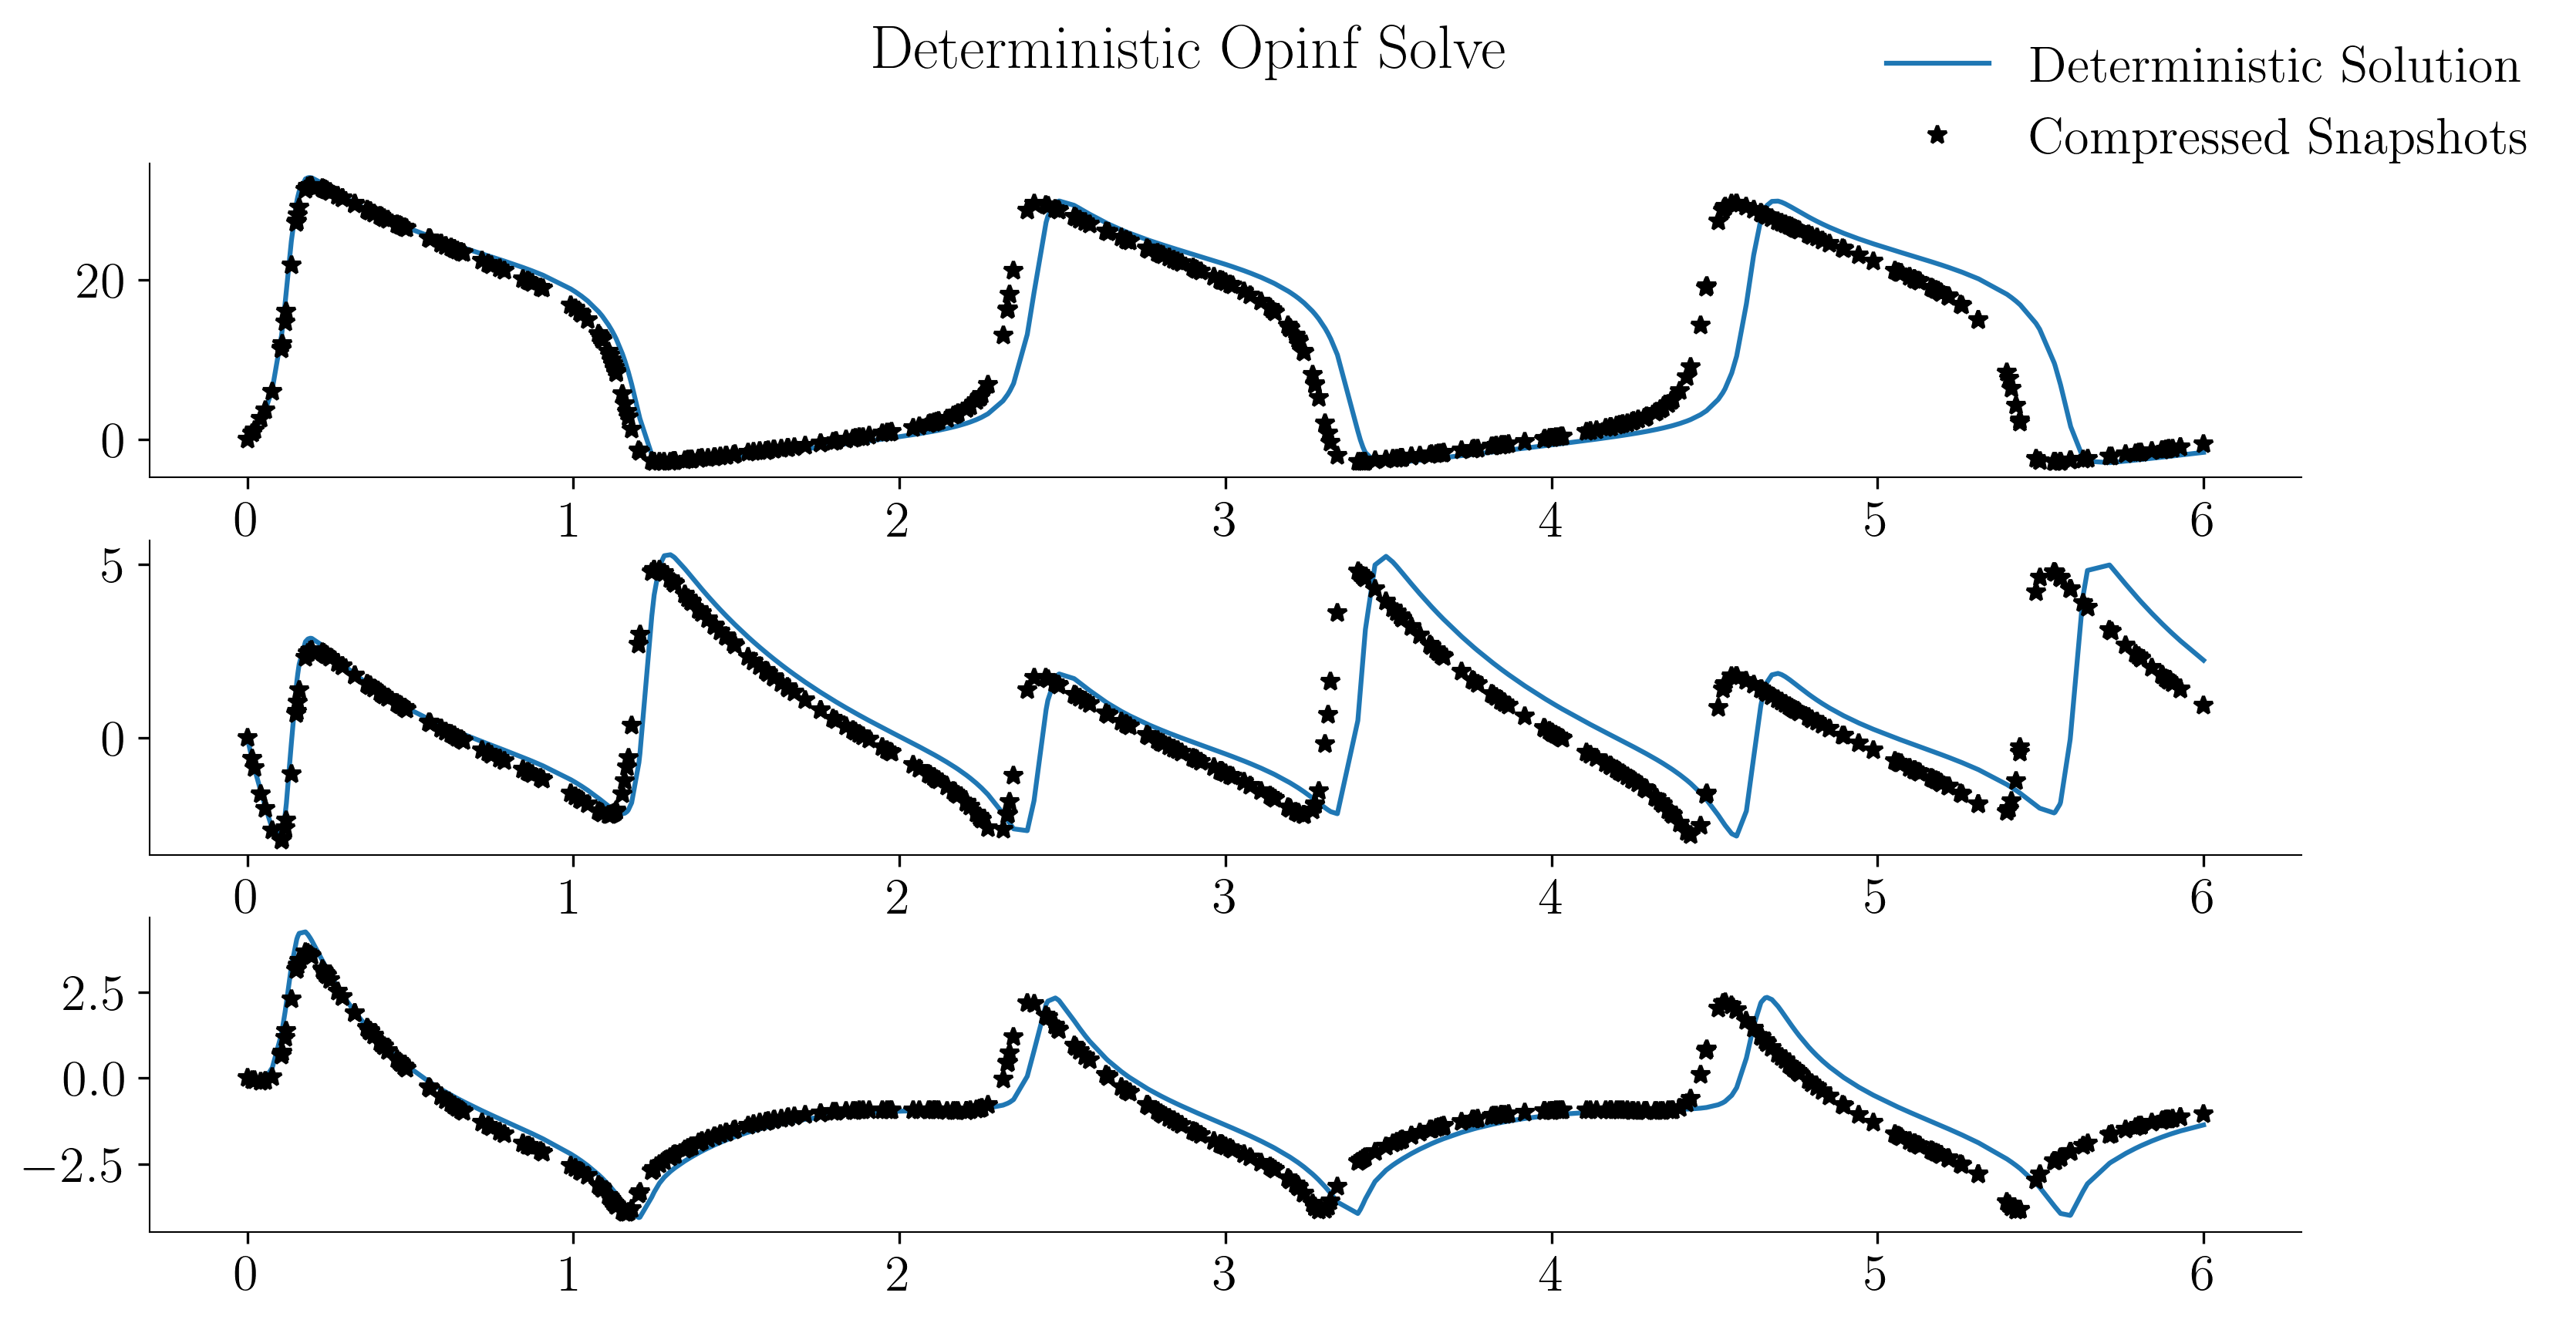

In [9]:
D = rom.model._assemble_data_matrix(snapshots_compressed, inputs)
D.shape

fig, ax = plt.subplots(numPODmodes, 1, figsize=figsize)

for i in range(numPODmodes):
    ax[i].plot(time_domain_sampled, deter_pred[i], label='Deterministic Solution')
    ax[i].plot(time_domain_sampled, snapshots_compressed[i], 'k*', label = 'Compressed Snapshots')

fig.suptitle('Deterministic Opinf Solve')
# 2) One legend for everything: grab handles & labels from *one* Axes
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc='upper right',   # you can choose 'upper right', etc.
           frameon=False,        # no box if you like
           )
fig.show()

In [10]:
K_yys = jnp.stack([gp.get_kernel_matrix(time_domain_sampled, nugget=1e-4) for gp in gps])
K_zys = jnp.stack([gp.get_kernel_derivative_dt1(time_domain_sampled) for gp in gps])
K_zzs = jnp.stack([gp.get_kernel_double_derivative(time_domain_sampled) for gp in gps])
noise_vars = jnp.array([gp.hyperparameters["noise"] for gp in gps])[:, None]*jnp.ones(time_domain_sampled.size)
sigma_zi = jnp.array([gp.get_As(time_domain_sampled)[0] for gp in gps])
Ds = jnp.stack([
    # gp.get_kernel_derivative_dt1(time) already does get_dash_c_phi(self.params, time)
    gp.get_kernel_derivative_dt1(time_domain_sampled) @ jnp.linalg.solve(K_yys[idx], jnp.eye(time_domain_sampled.shape[0]))
    for idx, gp in enumerate(gps)
])

/var/folders/z5/hb7nxgp524b67trvdyv41twh0000gn/T/ipykernel_56679/1013483183.py:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


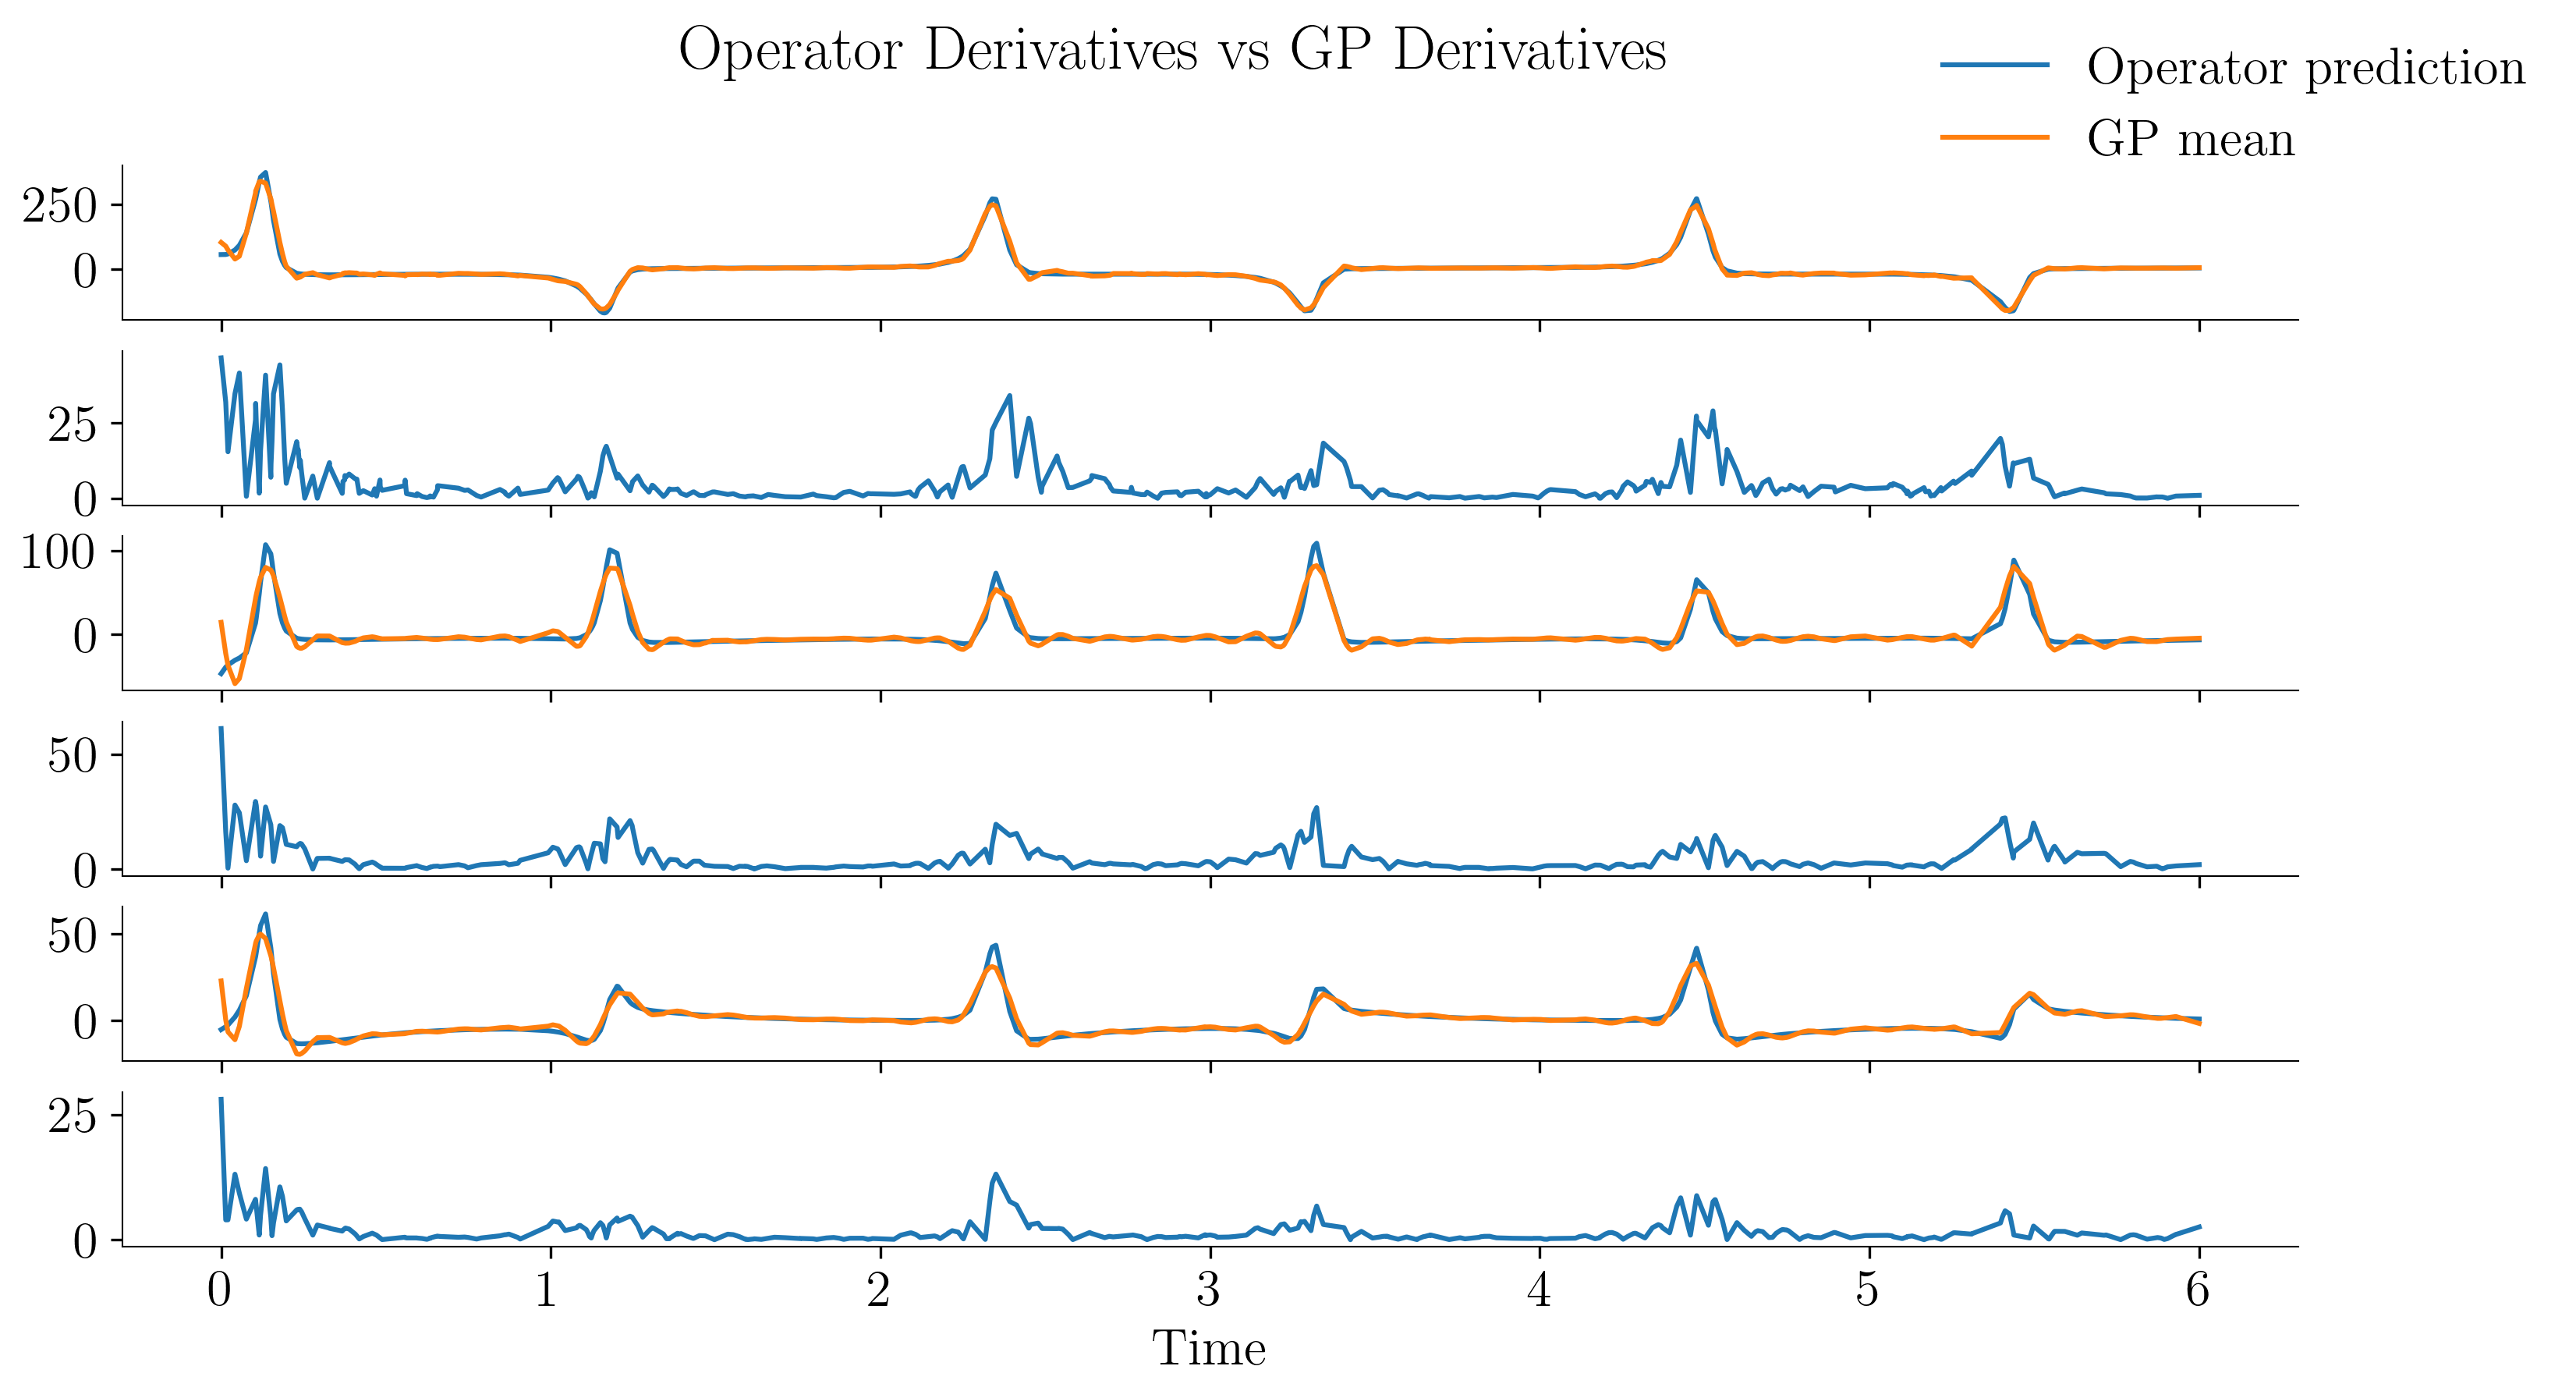

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# assuming z has shape (T, numPODmodes) so that z.T[i] is length‐T
z = (D @ prior_ohat.T)
mu_zi = jnp.einsum('bij,bj->bi', Ds, snapshots_compressed)  # shape (numPODmodes, T)

fig, ax = plt.subplots(numPODmodes*2, 1, figsize=figsize, sharex=True)

for i in range(numPODmodes):
    ax_pred = ax[2*i]         # even index: prediction vs GP
    ax_err  = ax[2*i + 1]     # odd  index: errors

    # —— prediction plot —— #
    ax_pred.plot(time_domain_sampled, z.T[i],     label='Operator prediction')
    ax_pred.plot(time_domain_sampled, mu_zi[i],   label='GP mean')
    # ax_pred.set_title(f'Mode {i}: prediction vs GP')

    # —— error plot —— #
    diff     = z.T[i] - mu_zi[i]
    abs_err  = np.abs(diff)
    pct_err  = abs_err / (np.abs(np.array(mu_zi[i])) + 1e-12) * 100

    ax_err.plot(time_domain_sampled, abs_err, label='Absolute error')

# common x‐label and tight layout
ax[-1].set_xlabel('Time')
fig.suptitle('Operator Derivatives vs GP Derivatives')
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc='upper right',   # you can choose 'upper right', etc.
           frameon=False,        # no box if you like
           )
fig.show()


### Probabilistic Model

In [12]:
import numpy as onp
import jax
import jax.numpy as jnp
from jax.experimental import io_callback
import numpyro
import numpyro.distributions as dist

def is_unstable(oi, n_time):
    """
    Returns a boolean indicating if the system is unstable.
    Uses JAX-compatible operations only.
    """
    pred = rom.model.predict_dynamic(
        state0=snapshots_compressed[:,0], 
        t=time_domain_sampled, 
        input_func=config.ReducedOrderModel.input_func_jax, 
        oi=oi
    )
    sol = rom.model.predict_result_
    
    is_unstable_flag = jnp.any(jnp.abs(sol.ys) > 50)
    print(is_unstable_flag)
    
    # Return True if unstable, False if stable
    return is_unstable_flag

def model(rom, nmodes, io_dims, gamma, prior_ohat, Q, Kyys, chi, sigma_zi, Ds):
    n_time = Q.shape[1]
    
    # Sample oi for all modes
    oi = numpyro.sample('oi', 
                        dist.Normal(prior_ohat, jnp.ones_like(prior_ohat)*(.001)).to_event(2)) # .001
    
    # 2) compute a *single* stability flag
    #    (True if *all* rows are stable)
    # stable = ~is_unstable(oi, n_time)

    # 3) assign a *finite* penalty: 
    #    zero if stable, otherwise -1e6 (you can pick any large number)
    # penalty = jnp.where(stable, 0.0, -1e6)
    # numpyro.factor("reject_unstable", penalty)
    
    # Sample Xi for all modes - this is the key fix
    Xi = numpyro.sample('Xi',
                        dist.MultivariateNormal(
                            jnp.zeros(n_time), 
                            Kyys  
                        ).to_event(1))  
    
    # Observe Yi for all modes
    if chi > 0:
        obs_cov = chi * jnp.eye(n_time)
        obs_cov_batch = jnp.repeat(obs_cov[None, :, :], nmodes, axis=0)
        numpyro.sample('Yi',
                      dist.MultivariateNormal(Xi, obs_cov_batch).to_event(1),
                      obs=Q)
    else:
        # Use small noise for numerical stability
        obs_cov = 1e-6 * jnp.eye(n_time)
        obs_cov_batch = jnp.repeat(obs_cov[None, :, :], nmodes, axis=0)
        numpyro.sample('Yi',
                      dist.MultivariateNormal(Xi, obs_cov_batch).to_event(1),
                      obs=Q)
    
    f_Xi_ohat = rom.model._assemble_data_matrix(Xi, inputs) @ oi.T
    
    mu_zi = jnp.einsum('bij,bj->bi', Ds, Xi)

    constraint_cov = sigma_zi + gamma[:, None, None] * jnp.eye(n_time)[None,:, :] 
    
    numpyro.sample(
        'ode_constraint',
        dist.MultivariateNormal(mu_zi, constraint_cov).to_event(1),
        obs=f_Xi_ohat.T
    )

/Users/anthonypoole/miniconda3/envs/jax/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
from numpyro.infer import NUTS, MCMC

nuts_kernel = NUTS(model,
                #    dense_mass = True,          
                #    target_accept_prob = 0.9
                   )

mcmc = MCMC(nuts_kernel,
            num_warmup  = 100,               
            num_samples = 200,
            # thinning    = 2
            )


# Then run your MCMC with the fixed model:
mcmc.run(rom=rom, 
         nmodes=numPODmodes, 
         io_dims=14,
         gamma=1e2*np.array([5,1,1]),
         prior_ohat=prior_ohat,
         Q=snapshots_compressed,
         Kyys=K_yys,
         chi=1e-6,  # <-- CHANGE: Use small positive value instead of 0
         sigma_zi=sigma_zi,
         Ds=Ds,
         rng_key=jax.random.PRNGKey(0))
samples = mcmc.get_samples()

KeyboardInterrupt: 

### Analyze results

#### Derivative Predictions

/var/folders/z5/hb7nxgp524b67trvdyv41twh0000gn/T/ipykernel_49692/1872005007.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


(400, 3)
(400, 3)


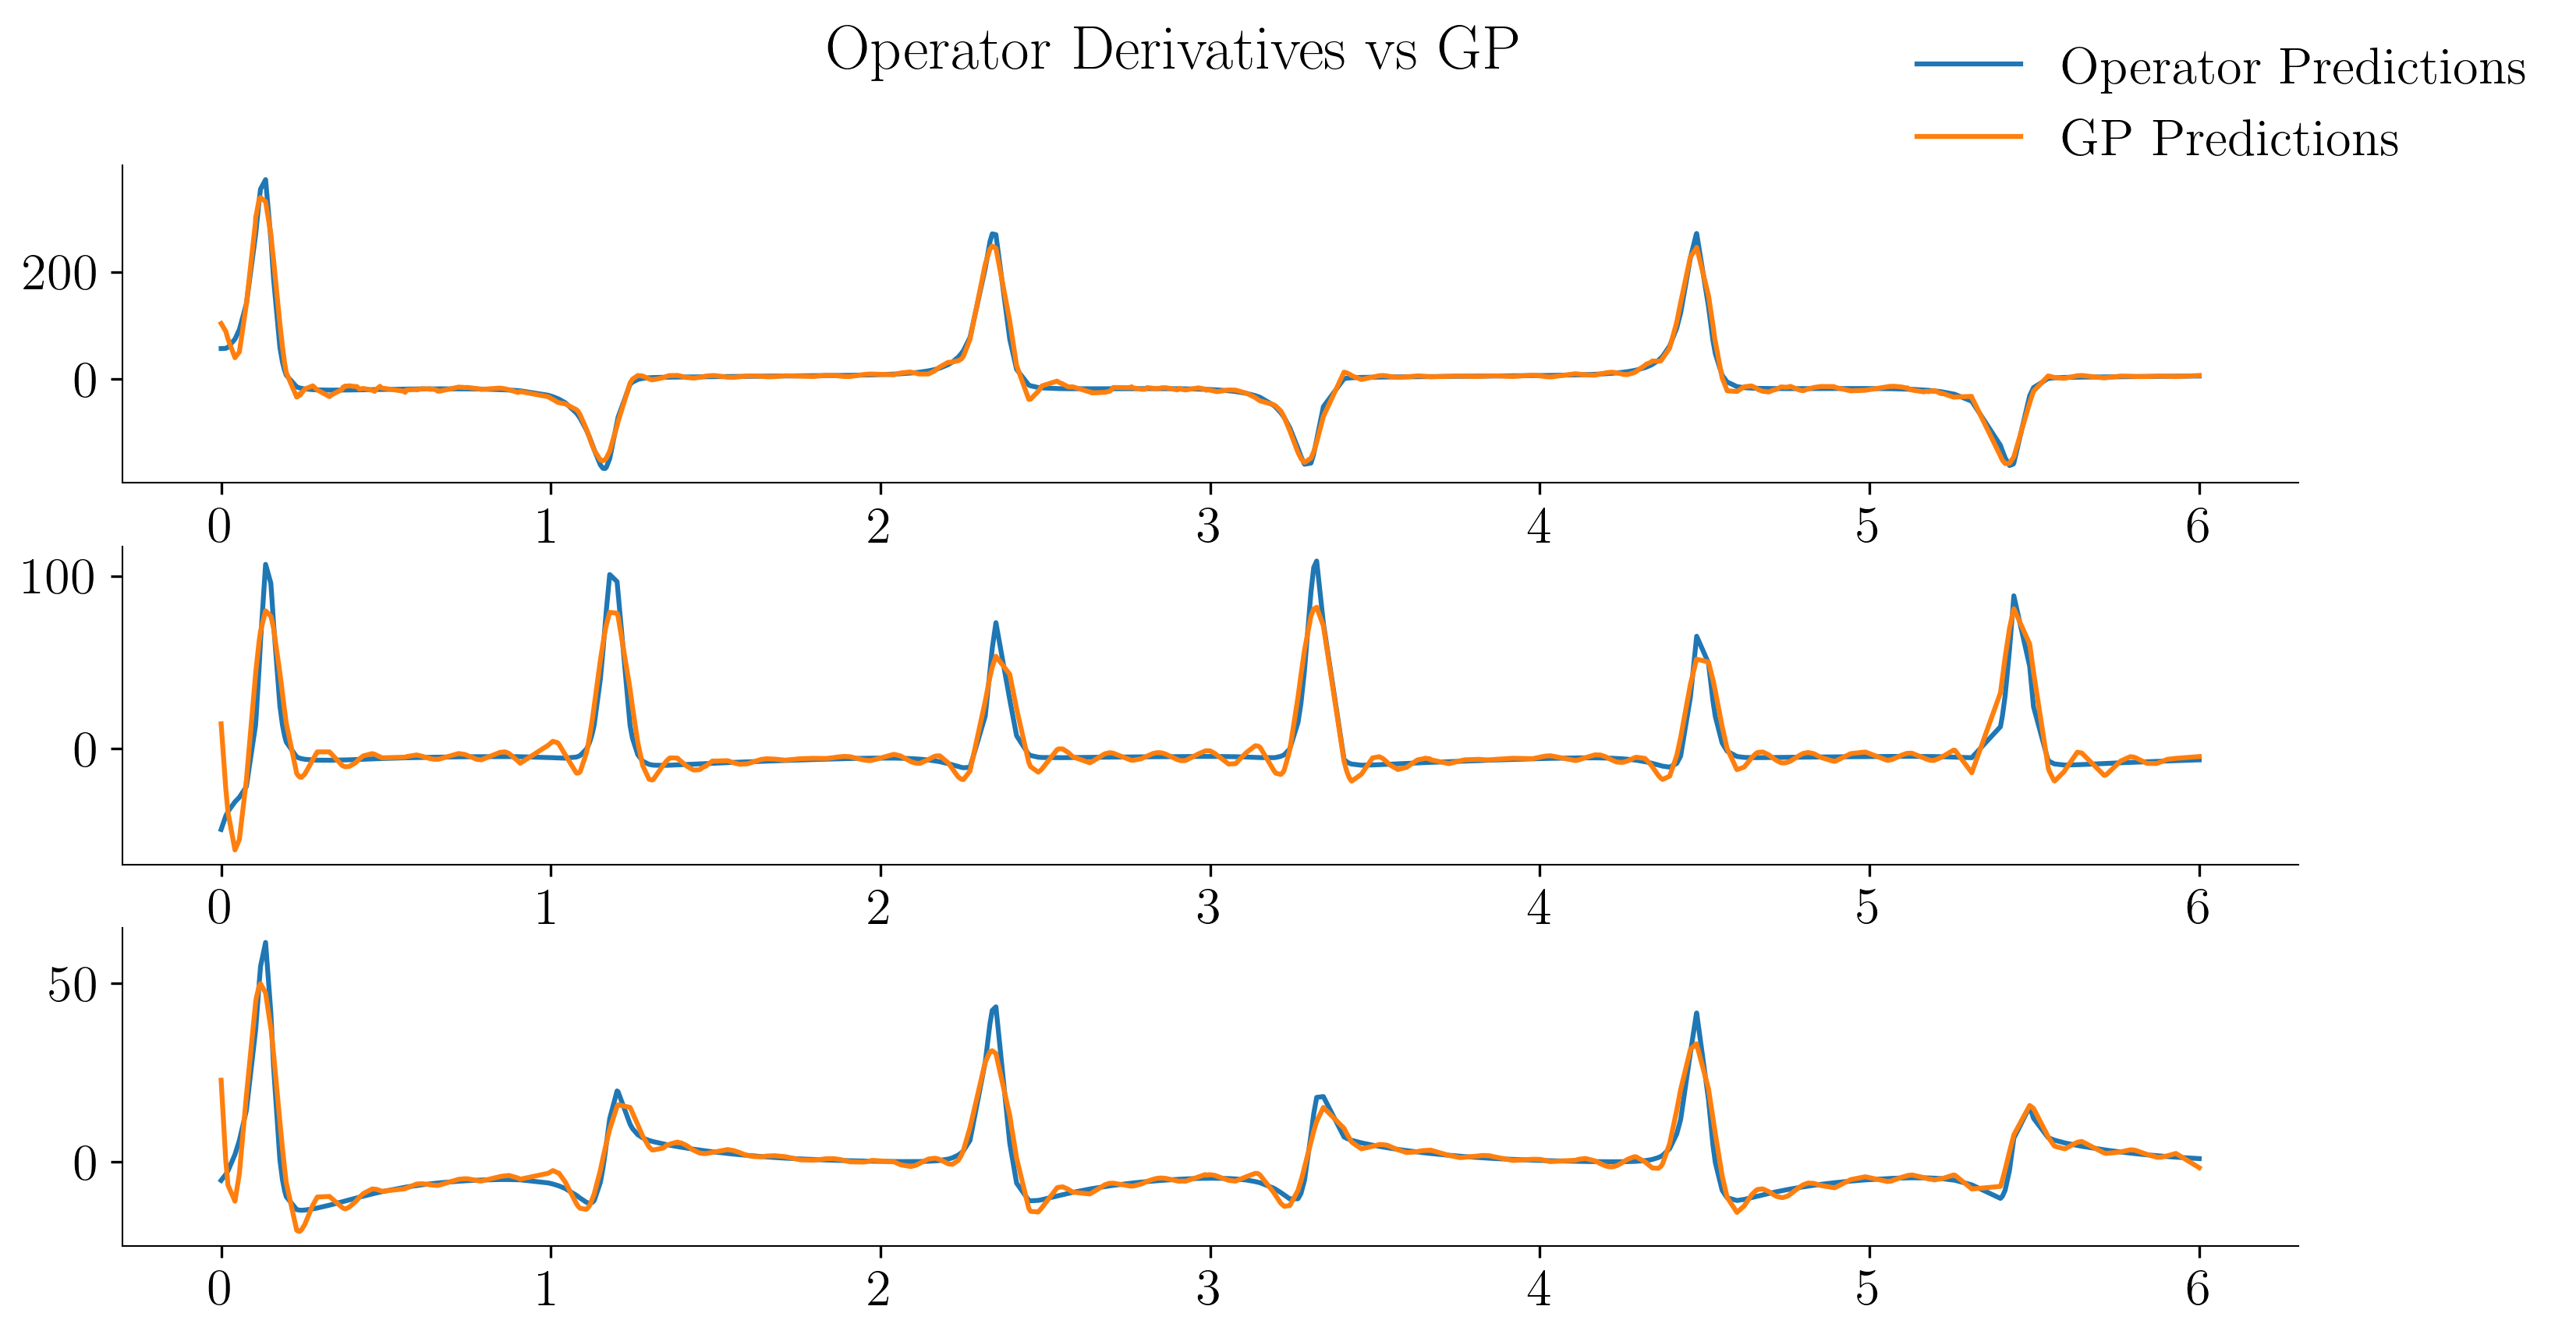

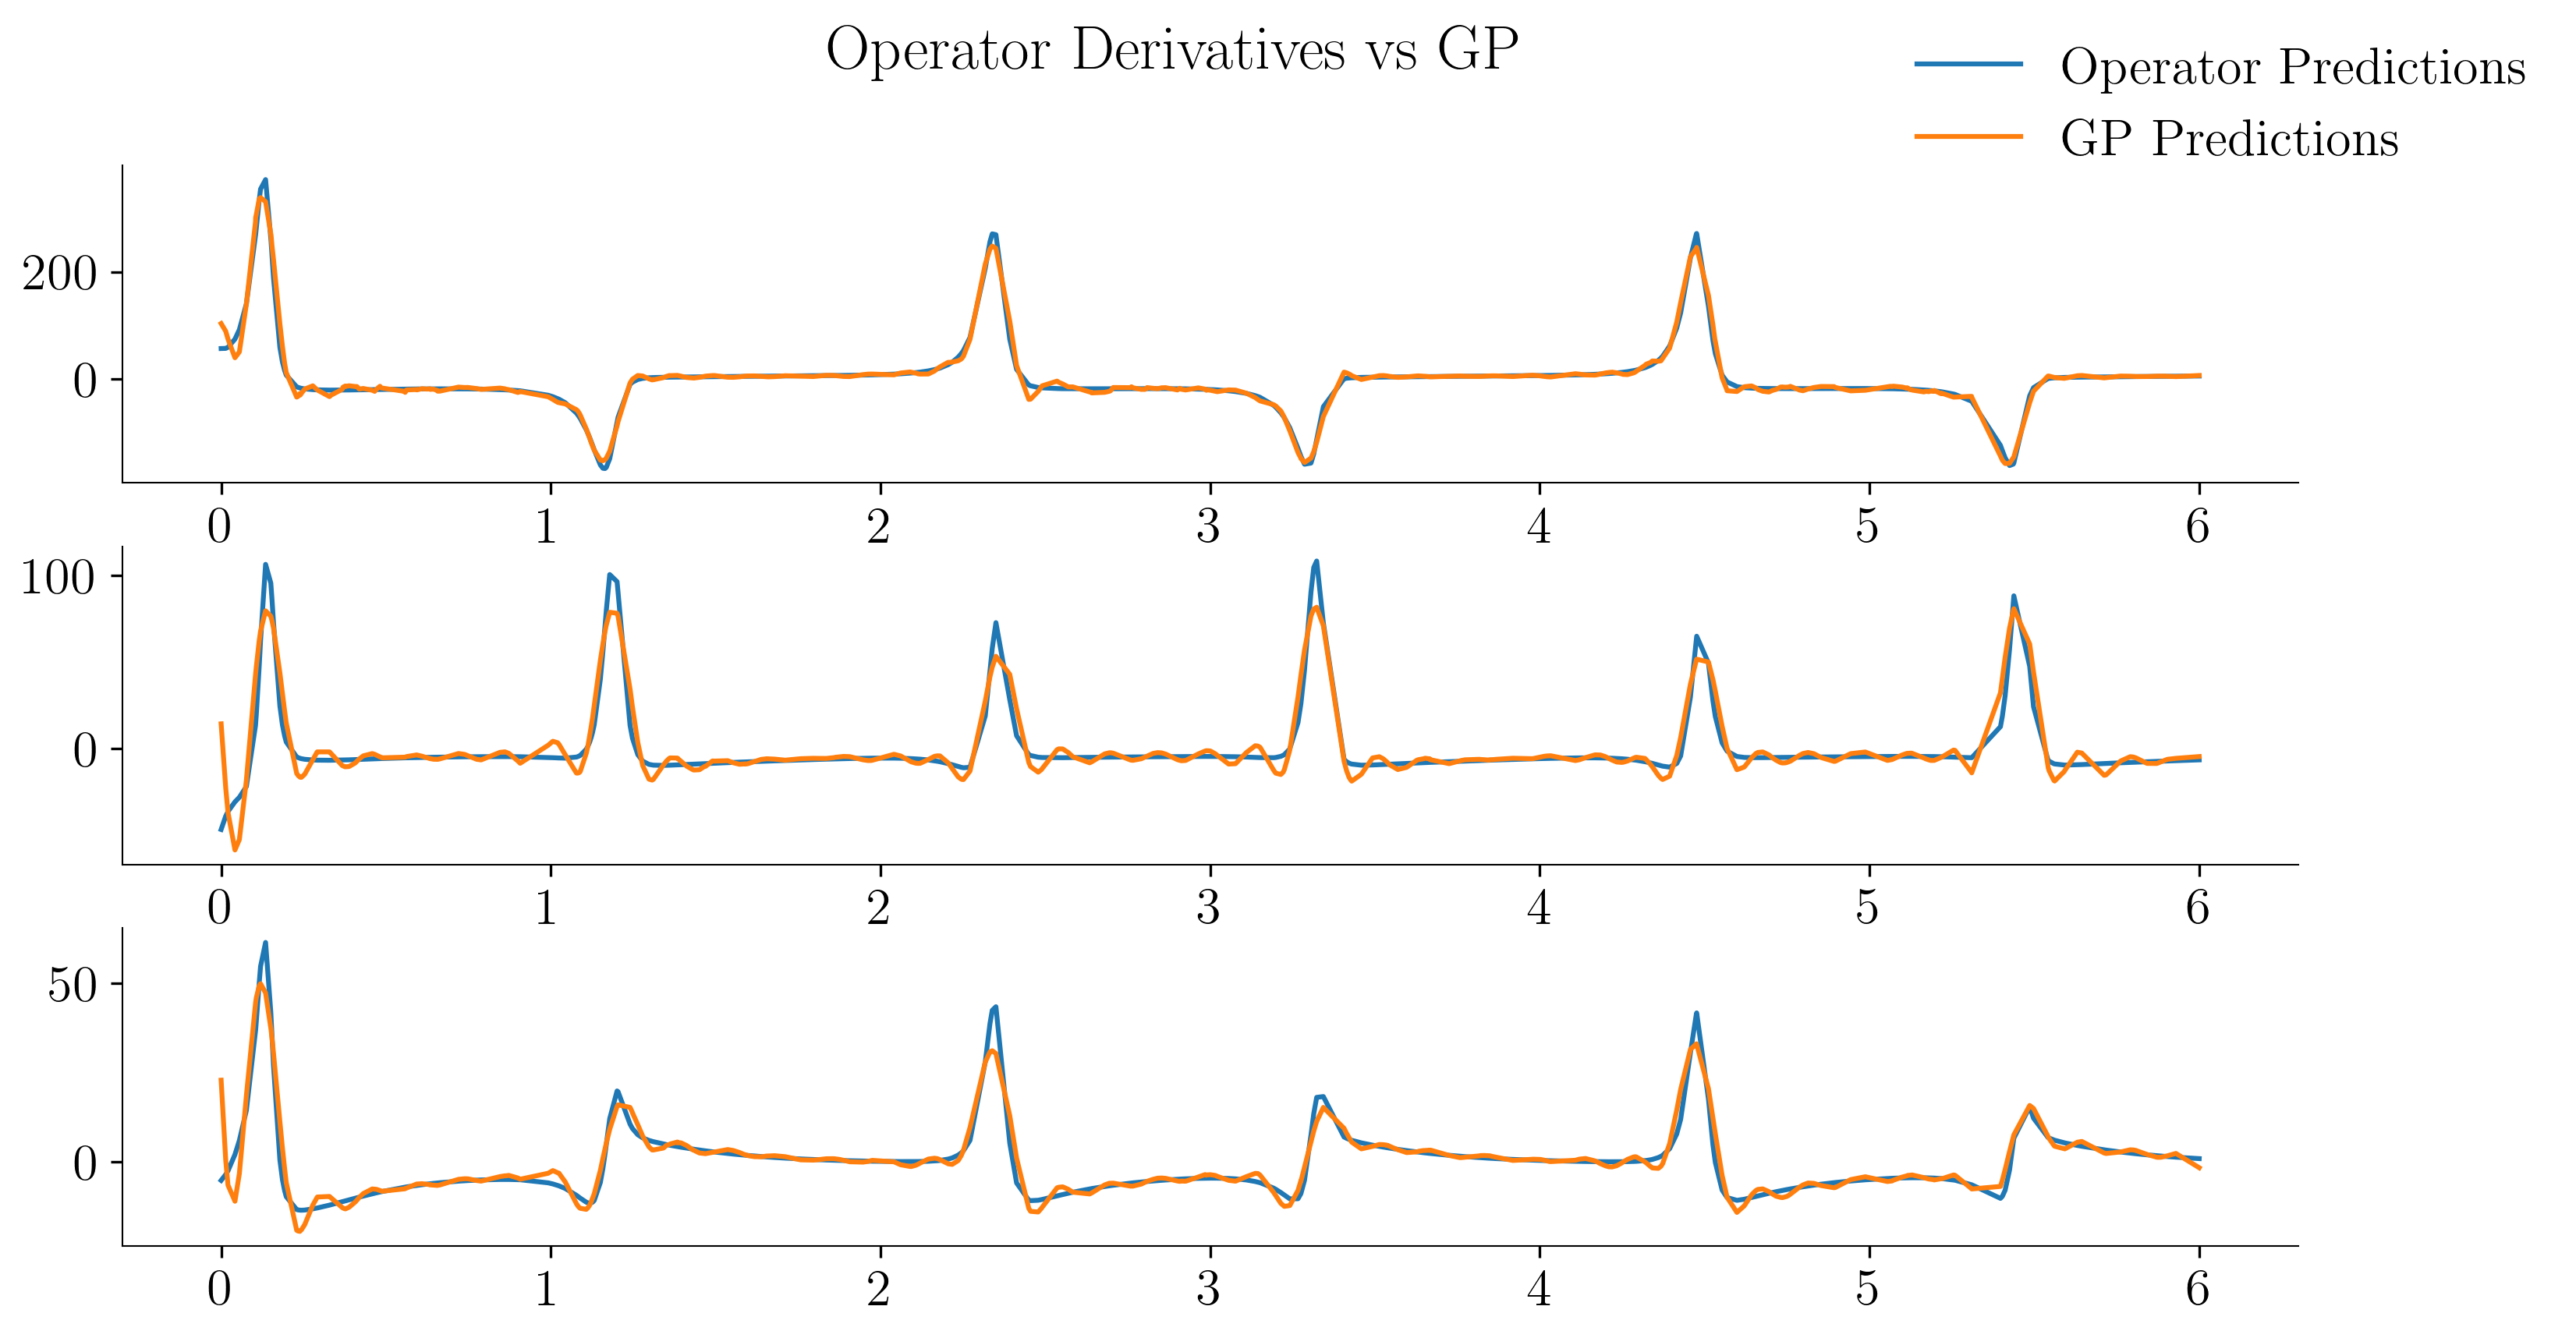

In [ ]:
mean_O = samples['oi'].mean(axis=0)
median_O = jnp.median(samples['oi'], axis=0)

for _ in range(2):
    if _ == 0:
        z = (D @ mean_O.T)
    else:
        z = (D @ median_O.T)

    print(z.shape)
    mu_zi = jnp.einsum('bij,bj->bi', Ds, snapshots_compressed)
    fig, ax = plt.subplots(numPODmodes, 1, figsize = figsize)
    for i in range(numPODmodes):
        ax[i].plot(time_domain_sampled, z.T[i], label='Operator Predictions')
        ax[i].plot(time_domain_sampled, mu_zi[i], label='GP Predictions')
    
    handles, labels = ax[0].get_legend_handles_labels()
    fig.legend(handles, labels,
            loc='upper right',   # you can choose 'upper right', etc.
            frameon=False,        # no box if you like
            )
    fig.suptitle('Operator Derivatives vs GP')
    fig.show()

#### Latent State Predictions

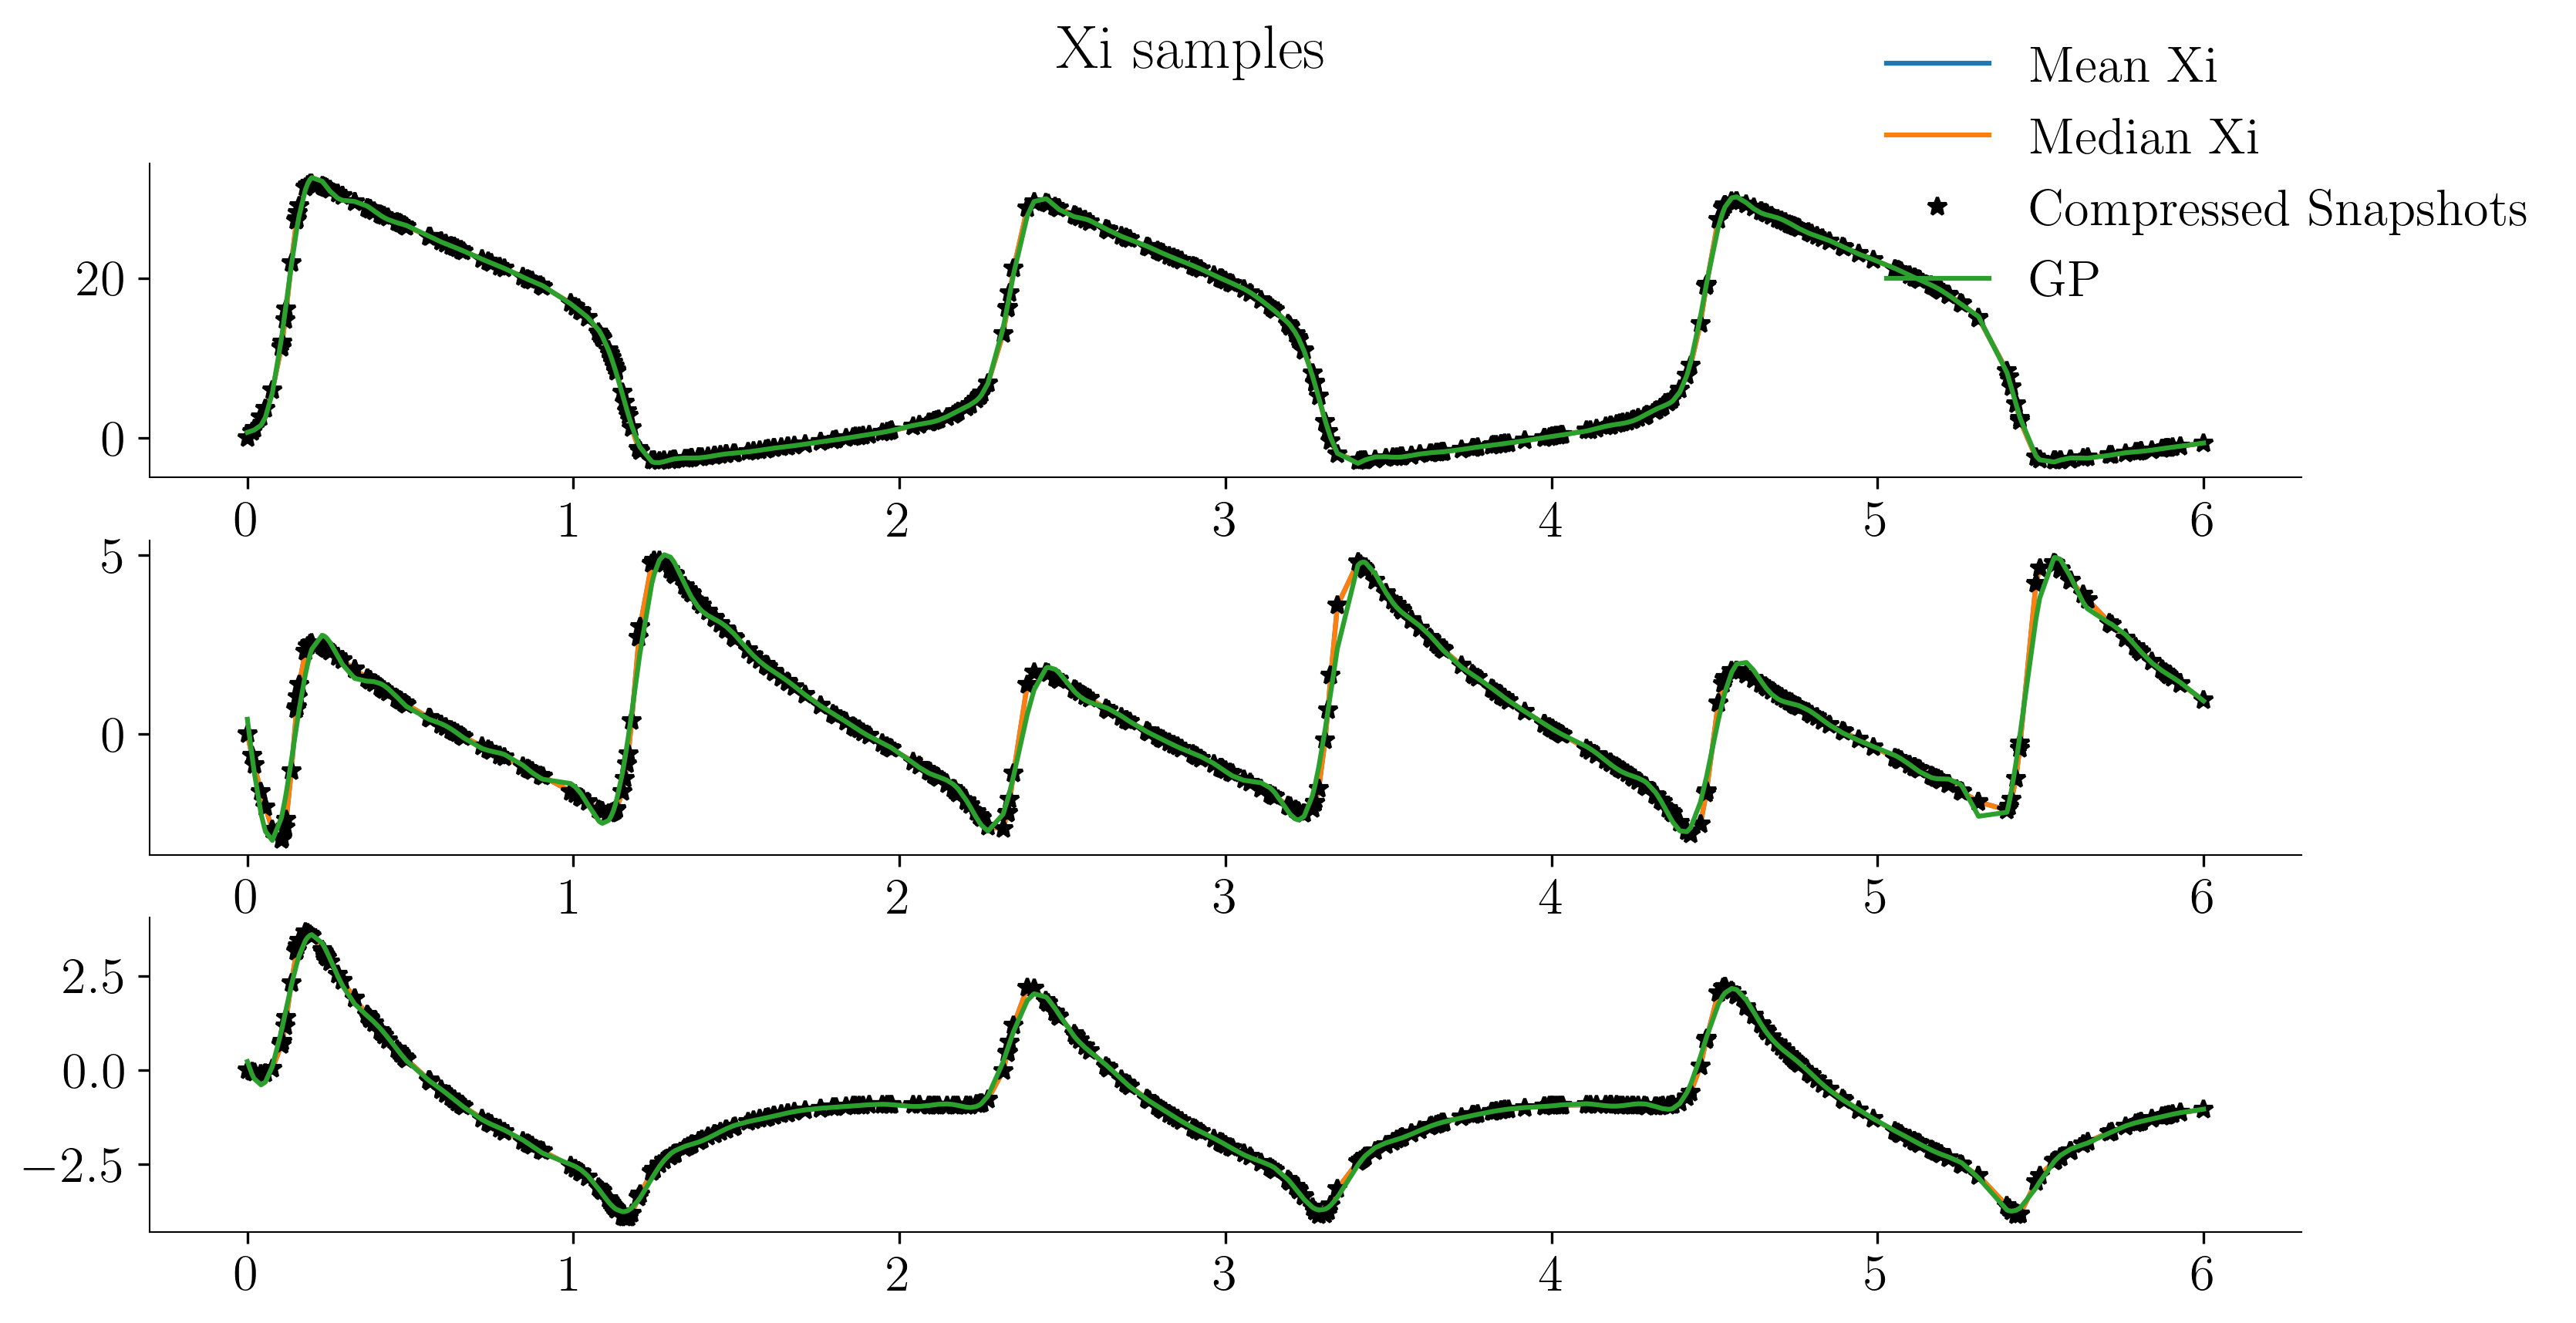

In [ ]:
mean_Xi = samples['Xi'].mean(axis=0)
median_Xi = jnp.median(samples['Xi'], axis=0)

fig, ax = plt.subplots(numPODmodes, 1, figsize=figsize)
for i in range(numPODmodes):
    ax[i].plot(time_domain_sampled, mean_Xi[i], label='Mean Xi')
    ax[i].plot(time_domain_sampled, median_Xi[i], label='Median Xi')
    ax[i].plot(time_domain_sampled, snapshots_compressed[i], 'k*', label='Compressed Snapshots')
    ax[i].plot(time_domain_sampled, gp_state_preds[i], label = 'GP')

fig.suptitle('Xi samples')
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels,
        loc='upper right',   # you can choose 'upper right', etc.
        frameon=False,        # no box if you like
        )

#### Comparision Between Deterministic Operator and Predicted Operator

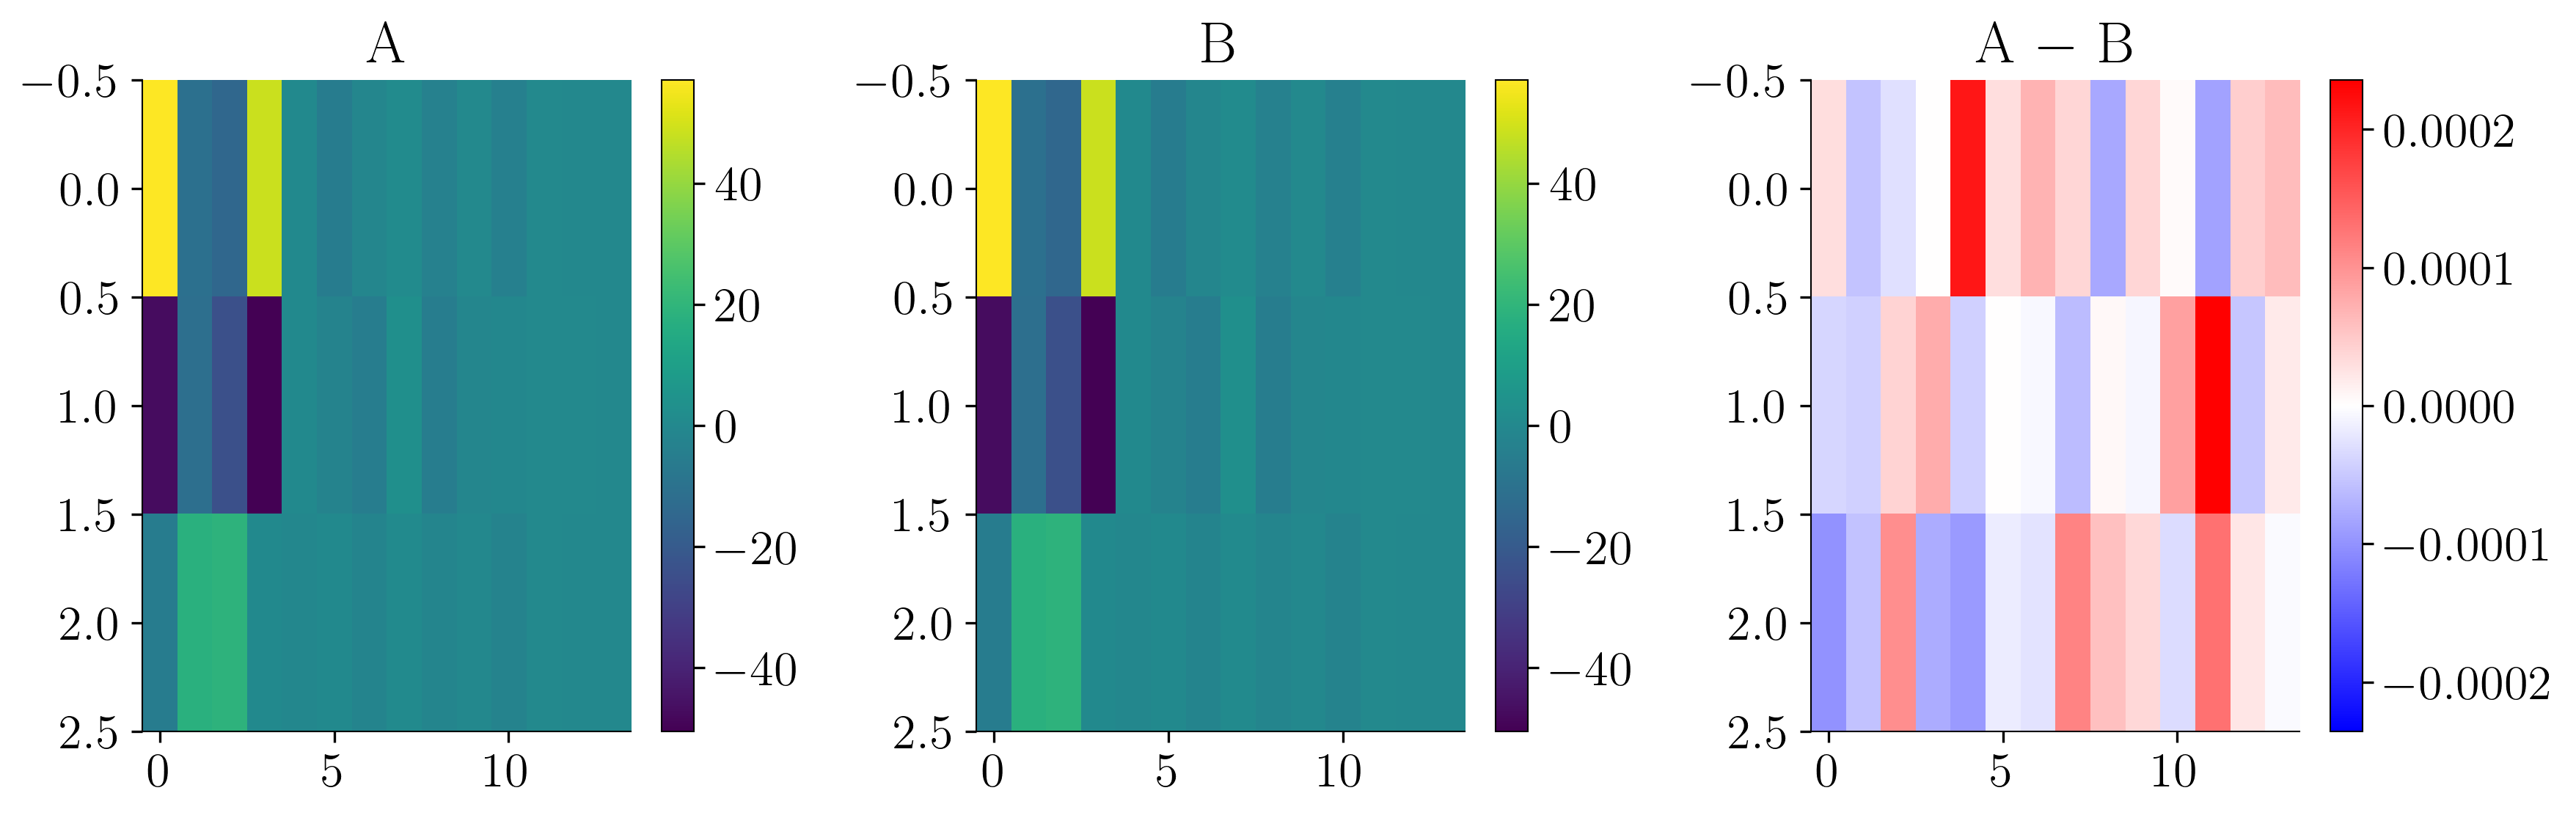

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

A, B = mean_O, prior_ohat
Dif = A - B

# A
im0 = axes[0].imshow(A, aspect='auto')
axes[0].set_title("A")
plt.colorbar(im0, ax=axes[0])

# B
im1 = axes[1].imshow(B, aspect='auto')
axes[1].set_title("B")
plt.colorbar(im1, ax=axes[1])

# Difference (use a diverging cmap)
im2 = axes[2].imshow(Dif, cmap='bwr', aspect='auto', vmin=-np.max(np.abs(Dif)), vmax=np.max(np.abs(Dif)))
axes[2].set_title("A − B")
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

/var/folders/z5/hb7nxgp524b67trvdyv41twh0000gn/T/ipykernel_49692/3629870775.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


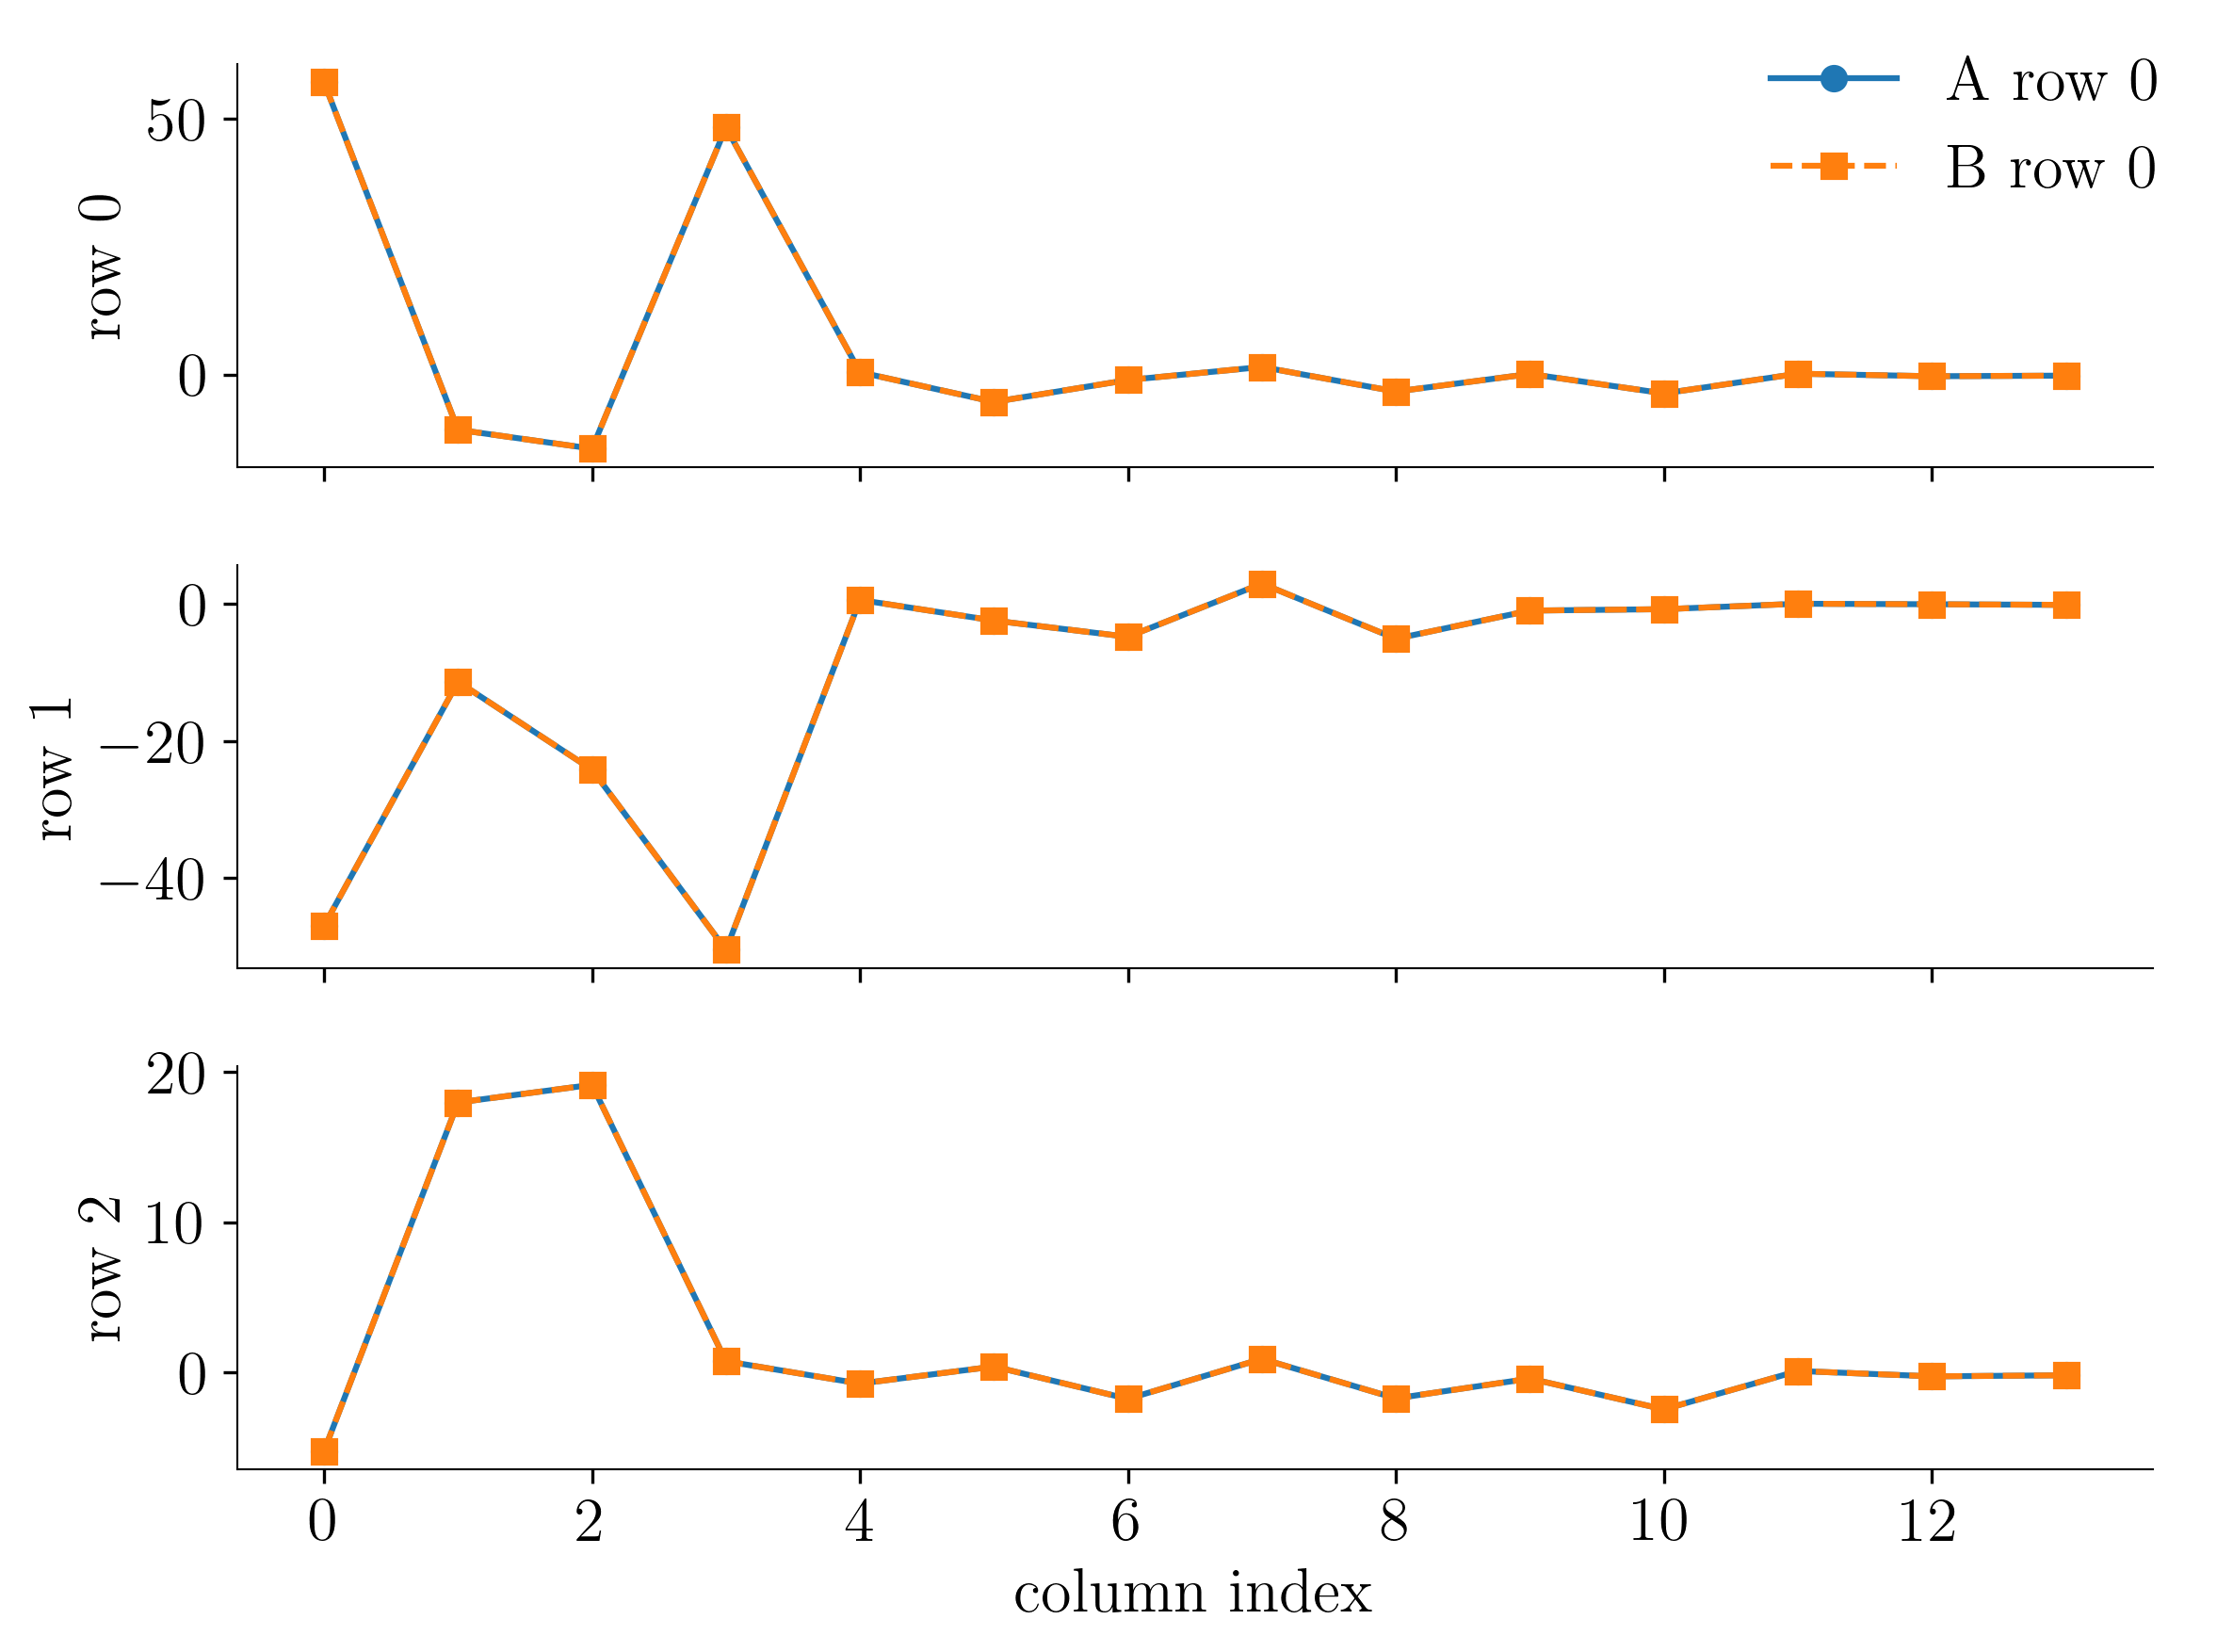

In [ ]:
fig, ax = plt.subplots(3, 1, figsize=(8, 6), sharex=True)

for i, axes in enumerate(ax):
    axes.plot(A[i],  '-o', label=f'A row {i}')
    axes.plot(B[i],  '--s', label=f'B row {i}')
    axes.set_ylabel(f'row {i}')

ax[-1].set_xlabel("column index")
plt.tight_layout()
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels,
        loc='upper right',   # you can choose 'upper right', etc.
        frameon=False,        # no box if you like
        )
fig.show()

#### Now the final state predictions as predicted from the Operator Matrix

(400,)


/var/folders/z5/hb7nxgp524b67trvdyv41twh0000gn/T/ipykernel_49692/456232406.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


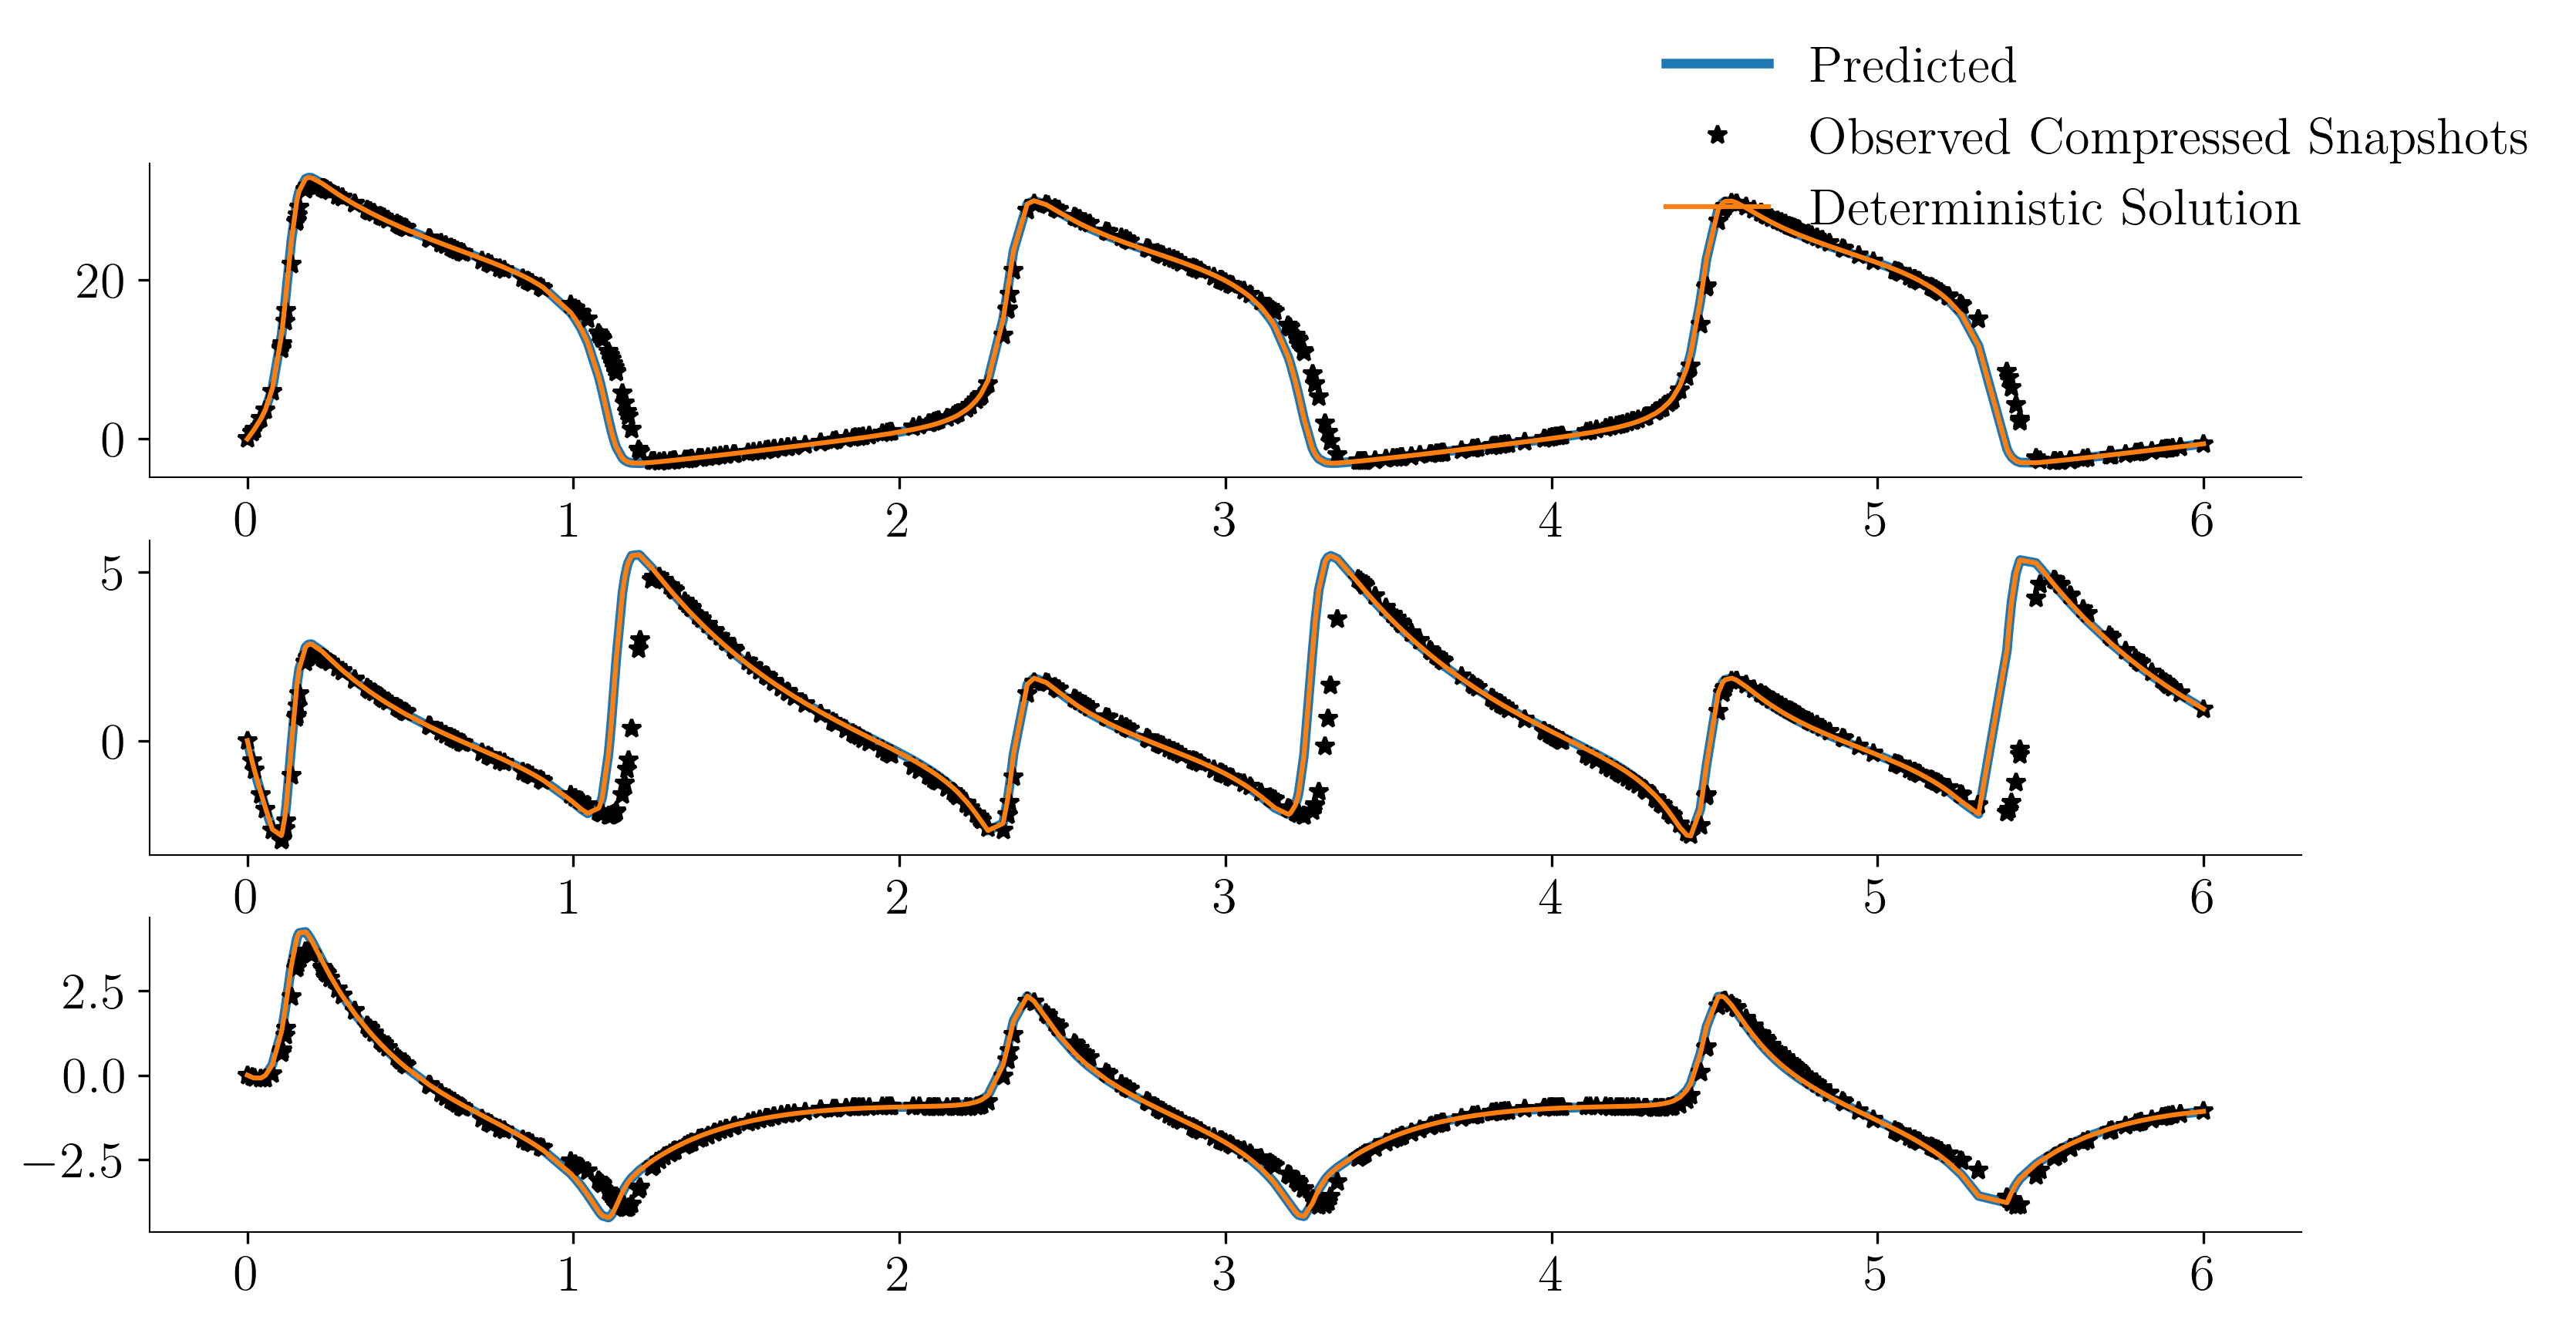

In [ ]:
# Plot predictions within training time domains
pred = rom.model.predict_dynamic(state0=snapshots_compressed[:,0], t=time_domain_sampled, input_func=config.ReducedOrderModel.input_func_jax, oi=mean_O)
sol = rom.model.predict_result_ 
print(sol.ts.shape)          

truncated_time_domain = time_domain_sampled[:np.searchsorted(time_domain_sampled, sol.ts[-1], side = 'right')]
truncated_compressed_snapshots = snapshots_compressed[:, :len(truncated_time_domain)]
fig, ax = plt.subplots(numPODmodes, 1, figsize=figsize)
for i in range(numPODmodes):
    ax[i].plot(sol.ts, pred[i], label = 'Predicted', lw = 3)
    ax[i].plot(truncated_time_domain, truncated_compressed_snapshots[i], 'k*', label = 'Observed Compressed Snapshots')
    if len(truncated_time_domain) == len(time_domain_sampled):
        ax[i].plot(time_domain_sampled, pred[i], label='Deterministic Solution')

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels,
        loc='upper right',   # you can choose 'upper right', etc.
        frameon=False,        # no box if you like
        )
fig.show()

/var/folders/z5/hb7nxgp524b67trvdyv41twh0000gn/T/ipykernel_49692/2083521114.py:59: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


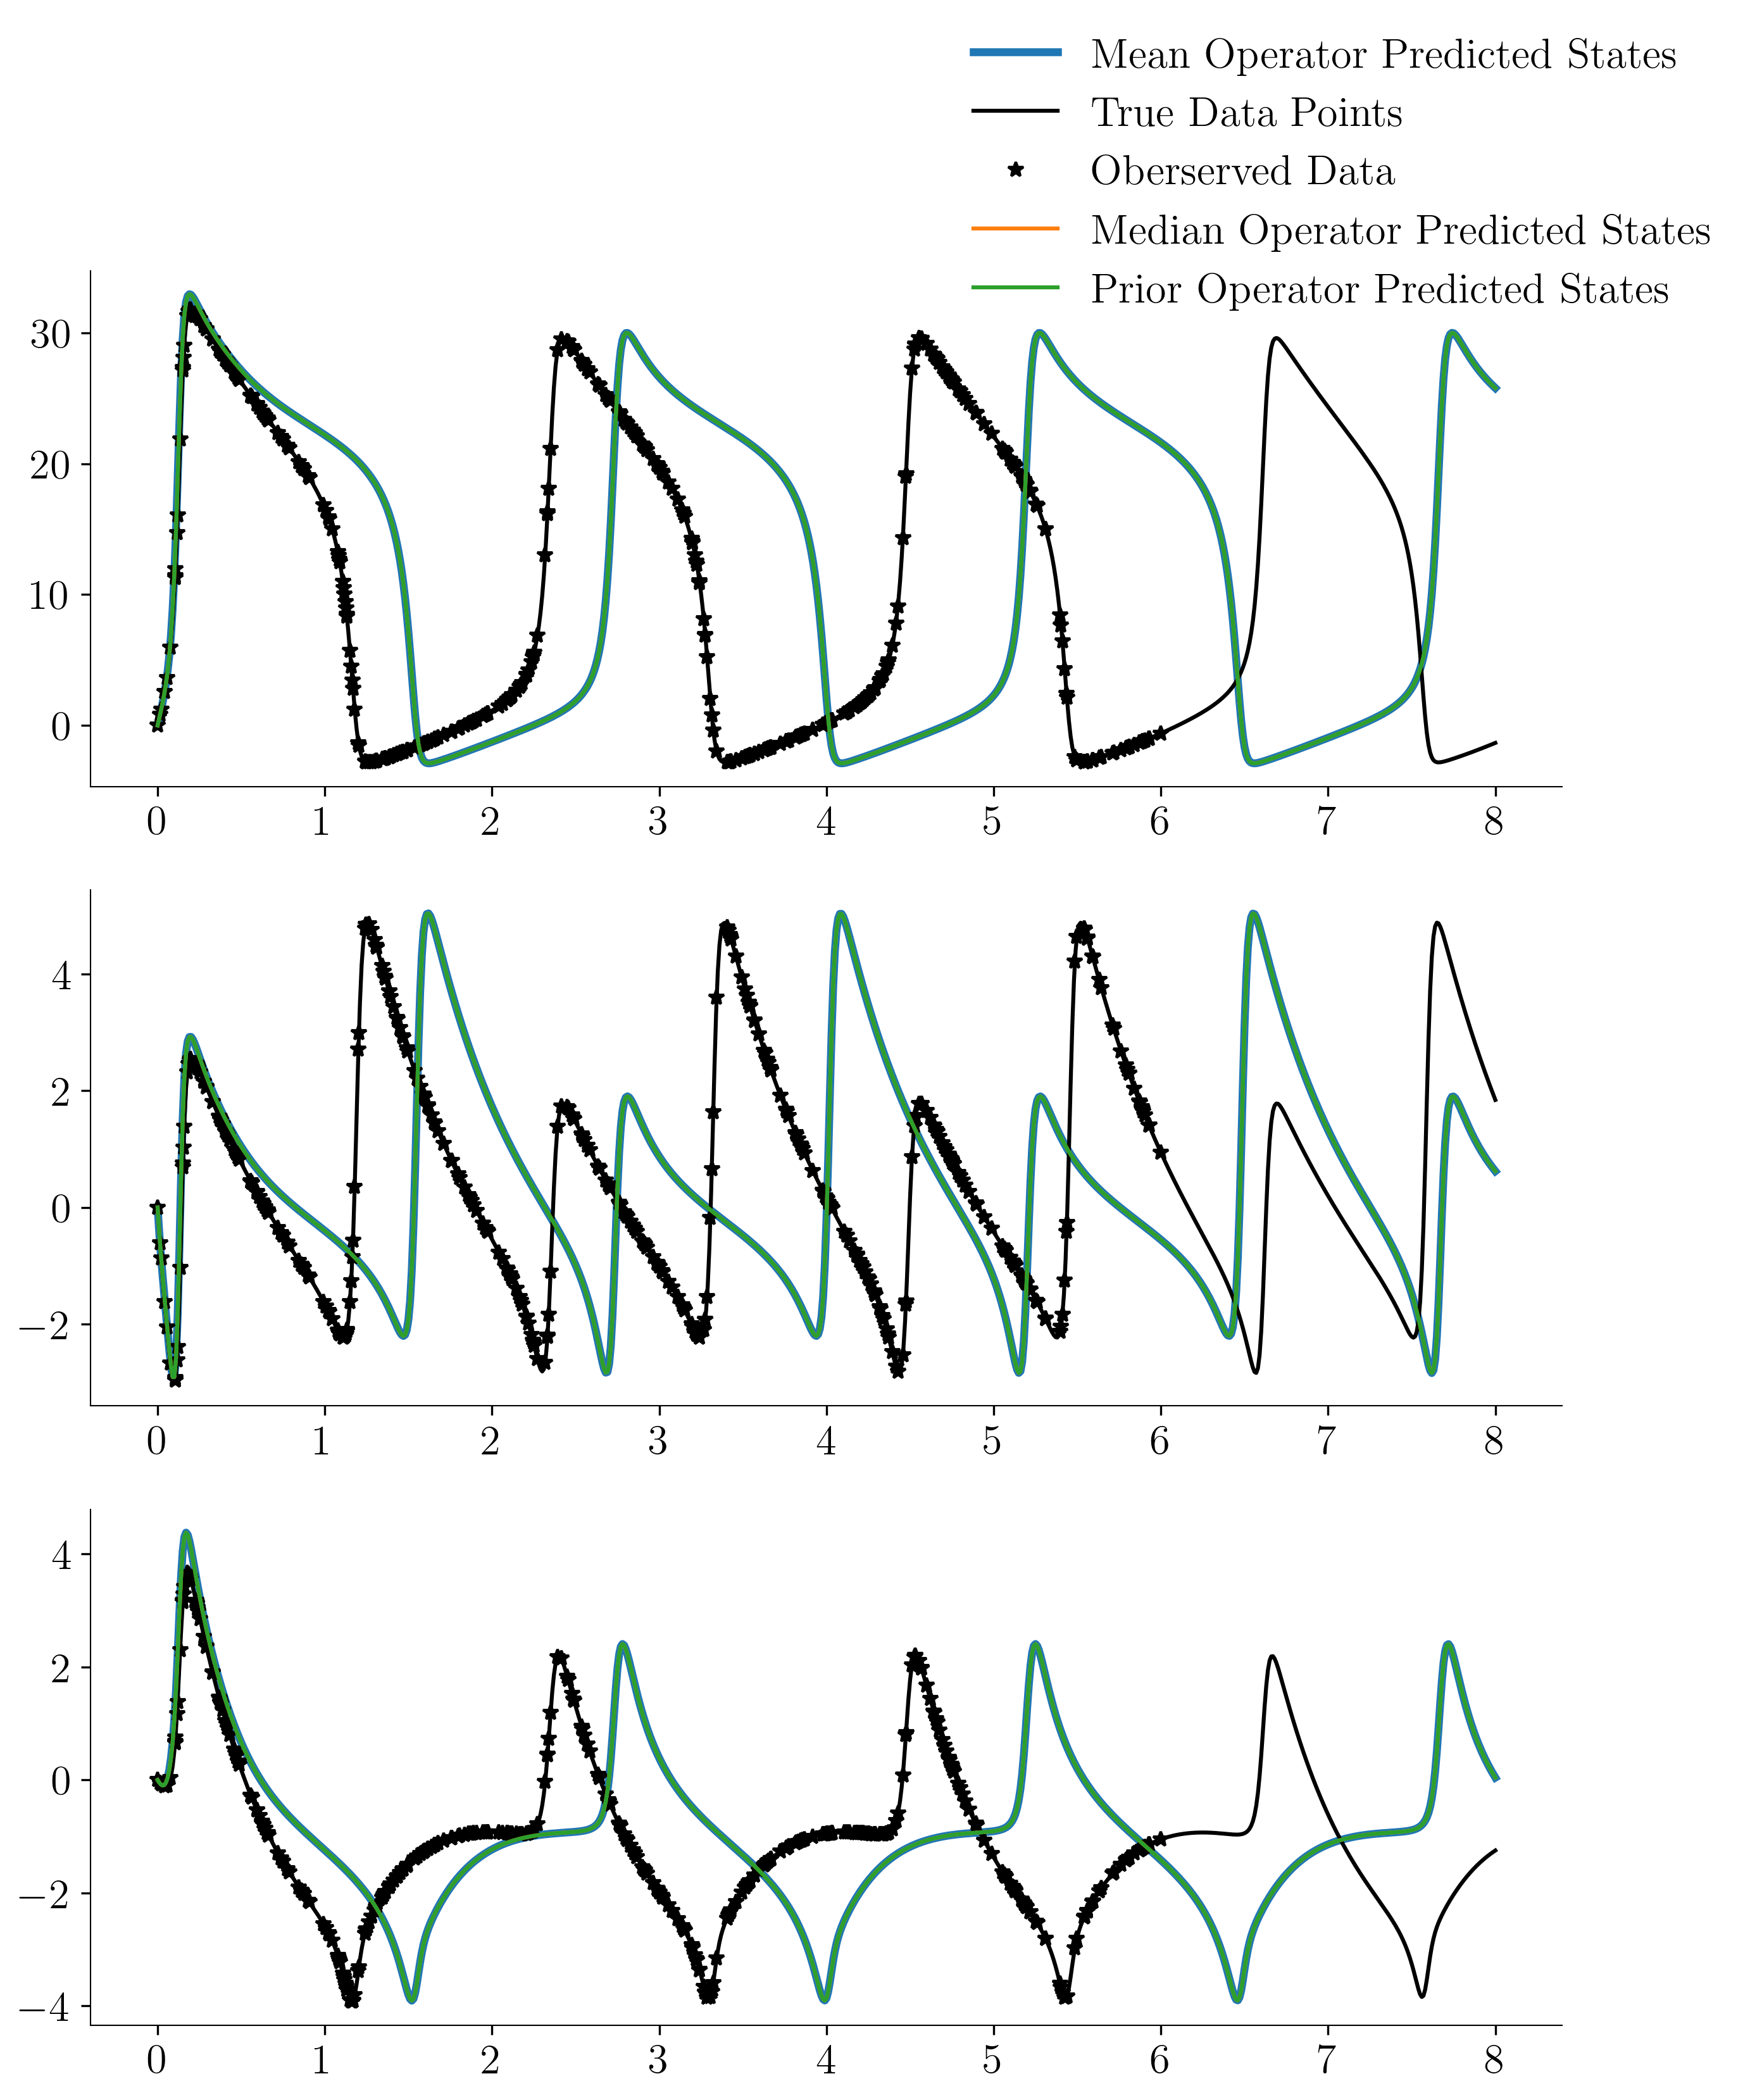

In [ ]:
# Take many samples from posterior
sampled_indices = set()
trajectories = []
for i in range(min(ndraws, len(samples['oi']))):
    rand_idx = np.random.randint(0, len(samples['oi']))
    while (rand_idx in sampled_indices):
        rand_idx = np.random.randint(0, len(samples['oi']))
    
    sampled_indices.add(rand_idx)
    rand_O = samples['oi'][rand_idx]

    pred = rom.model.predict_dynamic(state0=full_states_compressed[:,0], t=time_domain, input_func=config.ReducedOrderModel.input_func_jax, oi=rand_O)
    sol = rom.model.predict_result_ 
    
    if pred.size < full_states_compressed.size:
        print(f"Failed, don't include, stopped at step: {sol.t.size}")
    
    else:
        trajectories.append(pred)

# Compute the predictions as given by the prior
prior_pred = rom.model.predict_dynamic(state0=full_states_compressed[:,0], t=time_domain, input_func=config.ReducedOrderModel.input_func_jax, oi=prior_ohat)
prior_sol = rom.model.predict_result_ 

# Compute the predictions as given by the mean O
mean_pred = rom.model.predict_dynamic(state0=full_states_compressed[:,0], t=time_domain, input_func=config.ReducedOrderModel.input_func_jax, oi=mean_O)
mean_sol = rom.model.predict_result_ 

# Test if we even had any dubs
if len(trajectories) == 0:
    print("Failed to find any stable operators")

else:
    # Compute some things for the drawn trajectories
    trajectories = np.array(trajectories)
    q1 = np.percentile(trajectories, 25, axis=0)
    q3 = np.percentile(trajectories, 75, axis=0)
    median_traj = np.median(trajectories, axis=0)

    fig, ax = plt.subplots(3, 1, figsize=(10,12))
    for i in range(numPODmodes):
        # Plot mean prediction vs observed
        ax[i].plot(mean_sol.ts, mean_pred[i], label = 'Mean Operator Predicted States', lw=3)
        ax[i].plot(time_domain, full_states_compressed[i], 'black', label = 'True Data Points')
        ax[i].plot(time_domain_sampled, snapshots_compressed[i], 'k*', label = 'Oberserved Data')

        # Plot the many trajectories stuff
        ax[i].plot(time_domain, median_traj[i], label = 'Median Operator Predicted States')
        ax[i].fill_between(time_domain, q1[i], q3[i], alpha=.2)

        # Plot the deterministic solve
        ax[i].plot(prior_sol.ts, prior_pred[i], label = 'Prior Operator Predicted States')

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels,
        loc='upper right',   # you can choose 'upper right', etc.
        frameon=False,        # no box if you like
        )
fig.show()

In [ ]:
# Take many samples from posterior
sampled_indices = set()
trajectories = []
for i in range(min(ndraws, len(samples['oi']))):
    rand_idx = np.random.randint(0, len(samples['oi']))
    while (rand_idx in sampled_indices):
        rand_idx = np.random.randint(0, len(samples['oi']))
    
    sampled_indices.add(rand_idx)
    rand_O = samples['oi'][rand_idx]

    pred = rom.model.predict_dynamic2(state0=full_states_compressed[:,0], t=time_domain, input_func=config.ReducedOrderModel.input_func_jax, oi=rand_O)
    sol = rom.model.predict_result_ 
    
    if pred.size < full_states_compressed.size:
        print(f"Failed, don't include, stopped at step: {sol.t.size}")
    
    else:
        trajectories.append(pred)

# Compute the predictions as given by the prior
prior_pred = rom.model.predict_dynamic2(state0=full_states_compressed[:,0], t=time_domain, input_func=config.ReducedOrderModel.input_func_jax, oi=prior_ohat)
prior_sol = rom.model.predict_result_ 

# Compute the predictions as given by the mean O
mean_pred = rom.model.predict_dynamic2(state0=full_states_compressed[:,0], t=time_domain, input_func=config.ReducedOrderModel.input_func_jax, oi=mean_O)
mean_sol = rom.model.predict_result_ 

# Test if we even had any dubs
if len(trajectories) == 0:
    print("Failed to find any stable operators")

else:
    # Compute some things for the drawn trajectories
    trajectories = np.array(trajectories)
    q1 = np.percentile(trajectories, 25, axis=0)
    q3 = np.percentile(trajectories, 75, axis=0)
    median_traj = np.median(trajectories, axis=0)

    fig, ax = plt.subplots(3, 1, figsize=(10,12))
    for i in range(numPODmodes):
        # Plot mean prediction vs observed
        ax[i].plot(mean_sol.ts, mean_pred[i], label = 'Mean Operator Predicted States', lw=3)
        ax[i].plot(time_domain, full_states_compressed[i], 'black', label = 'True Data Points')
        ax[i].plot(time_domain_sampled, snapshots_compressed[i], 'k*', label = 'Oberserved Data')

        # Plot the many trajectories stuff
        ax[i].plot(time_domain, median_traj[i], label = 'Median Operator Predicted States')
        ax[i].fill_between(time_domain, q1[i], q3[i], alpha=.2)

        # Plot the deterministic solve
        ax[i].plot(prior_sol.ts, prior_pred[i], label = 'Prior Operator Predicted States')

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels,
        loc='upper right',   # you can choose 'upper right', etc.
        frameon=False,        # no box if you like
        )
fig.show()

KeyboardInterrupt: 

### Random Things

#### See if we can do like a mini-unroll

In [ ]:
# time_domain_sampled[0]
# # time = 
# pred = rom.model.predict(state0=snapshots_compressed[:,0], t=np.array(time_domain_sampled[:2]), input_func=config.ReducedOrderModel.input_func_jax)
# sol = rom.model.predict_result_ 

# pred.shape

In [ ]:
# preds = []
# rom.model._extract_operators(np.array(mean_O))
# for i in range(len(time_domain_sampled)-1):
#     pred = rom.model.predict(state0=snapshots_compressed[:,i], t=np.array(time_domain_sampled[i:i+2]), input_func=config.ReducedOrderModel.input_func_jax)
#     sol = rom.model.predict_result_ 
#     preds.append(pred[:,0])

# preds = np.array(preds)

# plt.plot(time_domain_sampled[:-1], preds)
# plt.plot(time_domain_sampled[:-1], snapshots_compressed[:,:-1].T, 'k*')

In [ ]:
# ### Let's test this new predict thing
# maxes = snapshots_compressed.max(axis=1)
# print(maxes)

# while True:
#     oi = np.random.normal(prior_ohat, scale = 10)
    
#     pred = rom.model.predict_dynamic(state0=snapshots_compressed[:,0], t=time_domain_sampled, input_func=config.ReducedOrderModel.input_func_jax, oi=oi)
#     sol = rom.model.predict_result_

#     if np.any(pred.max(axis=1) >= maxes):
#         print(oi)
#         print(pred.shape)
#         plt.plot(sol.ts, pred.T)
#         break
